# Tech Challenge — Análise de crédito e classificação de atraso

### Contexto do problema

A análise do comportamento de pagamento dos clientes é relevante para instituições financeiras, pois permite compreender padrões associados ao risco de crédito e apoiar o desenvolvimento de estratégias de acompanhamento e gestão de carteira.

Neste projeto, investigamos se informações cadastrais, pessoais e financeiras apresentam associação com a ocorrência de atrasos de 60 dias ou mais no histórico de crédito disponível.

A proposta é avaliar o potencial e as limitações de modelos de classificação para identificar esses padrões, sem pressupor que os resultados sejam suficientes para decisões automáticas de concessão de crédito.

## Objetivo

Investigar se características cadastrais dos clientes permitem identificar
a ocorrência de atraso de 60 dias ou mais no histórico de crédito disponível.

O projeto utiliza aprendizado supervisionado para classificação,
clusterização para segmentação de perfis e análise temporal descritiva
dos registros mensais.

A variável-alvo é definida como:

- TARGET = 1: pelo menos um registro com STATUS entre 2 e 5;
- TARGET = 0: nenhum registro com STATUS entre 2 e 5 no histórico disponível.

A classificação é uma abordagem exploratória de apoio à análise de crédito.
Ela não representa uma decisão automática de aprovação de cartão nem
demonstra, por si só, previsão de inadimplência futura.

## Instruções de execução

O notebook pode ser executado no Google Colab.

1. Disponibilize na sessão o arquivo BaseDadosFase2.zip, contendo
   application_record.csv e credit_record.csv.
2. Verifique se o nome do arquivo ZIP corresponde exatamente
   ao utilizado na primeira célula de código.
3. Execute as células em ordem, do início ao fim.
4. Para verificar a execução sem depender de variáveis previamente
   criadas, utilize a opção “Reiniciar e executar tudo”.

O notebook utiliza pandas, NumPy, Matplotlib, seaborn,
scikit-learn, imbalanced-learn e Jinja2. As versões registradas
na execução de referência estão apresentadas ao final.

Os treinamentos e as validações cruzadas podem levar alguns minutos.
Os resultados salvos permitem consultar as análises sem executar
novamente todo o projeto.

As etapas que envolvem aleatoriedade foram configuradas com semente fixa (RANDOM_STATE = 42), favorecendo a reprodutibilidade dos resultados. Diferenças entre versões das bibliotecas ainda podem produzir pequenas variações.

In [1]:
# Semente fixa para reprodutibilidade
RANDOM_STATE = 42

## 1. Importação das bibliotecas e carregamento das bases

Foram utilizadas duas bases:
- `application_record.csv`: informações cadastrais, pessoais e financeiras dos clientes;
- `credit_record.csv`: histórico mensal de crédito dos clientes.

In [2]:
import pandas as pd
import zipfile

with zipfile.ZipFile("BaseDadosFase2.zip", "r") as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("application_record.csv")
df_credit = pd.read_csv("credit_record.csv")

pd.options.display.float_format = "{:,.2f}".format

In [3]:
df.shape, df_credit.shape

((438557, 18), (1048575, 3))

## 2. Inspeção inicial da base cadastral

Nesta etapa são avaliadas a dimensão da base, as variáveis disponíveis, os tipos de dados e a presença de valores ausentes.

### Dicionário de variáveis

As duas bases utilizadas podem ser relacionadas pela variável `ID`, que identifica o cliente. A seguir são apresentadas as variáveis disponíveis em cada dataset, conforme a documentação da fonte dos dados.

#### `application_record.csv`

| Variável | Descrição |
|---|---|
| `ID` | Identificador do cliente |
| `CODE_GENDER` | Gênero |
| `FLAG_OWN_CAR` | Indica se possui carro |
| `FLAG_OWN_REALTY` | Indica se possui imóvel |
| `CNT_CHILDREN` | Número de filhos |
| `AMT_INCOME_TOTAL` | Renda anual |
| `NAME_INCOME_TYPE` | Categoria da renda |
| `NAME_EDUCATION_TYPE` | Nível de escolaridade |
| `NAME_FAMILY_STATUS` | Estado civil |
| `NAME_HOUSING_TYPE` | Tipo de moradia |
| `DAYS_BIRTH` | Data de nascimento representada em dias, contados retrospectivamente a partir do dia de referência |
| `DAYS_EMPLOYED` | Data de início do emprego representada em dias, contados retrospectivamente a partir do dia de referência; segundo a documentação da fonte, valores positivos indicam pessoa atualmente desempregada |
| `FLAG_MOBIL` | Indica se possui telefone celular |
| `FLAG_WORK_PHONE` | Indica se possui telefone de trabalho |
| `FLAG_PHONE` | Indica se possui telefone |
| `FLAG_EMAIL` | Indica se possui e-mail |
| `OCCUPATION_TYPE` | Ocupação |
| `CNT_FAM_MEMBERS` | Número de membros da família |

#### `credit_record.csv`

| Variável | Descrição |
|---|---|
| `ID` | Identificador do cliente |
| `MONTHS_BALANCE` | Mês do registro em relação ao mês de referência: `0` representa o mês atual, `-1` o mês anterior e assim sucessivamente |
| `STATUS` | Situação do pagamento no respectivo mês |

**Códigos da variável `STATUS`:**

| Código | Significado |
|---|---|
| `0` | Atraso de 1 a 29 dias |
| `1` | Atraso de 30 a 59 dias |
| `2` | Atraso de 60 a 89 dias |
| `3` | Atraso de 90 a 119 dias |
| `4` | Atraso de 120 a 149 dias |
| `5` | Atraso ou dívida vencida por 150 dias ou mais |
| `C` | Quitado naquele mês |
| `X` | Sem empréstimo naquele mês |

> **Observação:** as descrições acima reproduzem, em português, o dicionário disponibilizado pela fonte do dataset. Particularidades encontradas durante a exploração, como o valor especial `365243` em `DAYS_EMPLOYED`, são investigadas nas etapas seguintes.

In [4]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,"427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00
1,5008805,M,Y,Y,0,"427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00
2,5008806,M,Y,Y,0,"112,500.00",Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.00
3,5008808,F,N,Y,0,"270,000.00",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00
4,5008809,F,N,Y,0,"270,000.00",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00


In [5]:
df.shape

(438557, 18)

In [6]:
df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [8]:
df.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [9]:
df.isnull().sum() / df.shape[0] * 100

,0
ID,0.00
CODE_GENDER,0.00
FLAG_OWN_CAR,0.00
FLAG_OWN_REALTY,0.00
CNT_CHILDREN,0.00
AMT_INCOME_TOTAL,0.00
NAME_INCOME_TYPE,0.00
NAME_EDUCATION_TYPE,0.00
NAME_FAMILY_STATUS,0.00
NAME_HOUSING_TYPE,0.00


## 3. Análise dos valores ausentes em OCCUPATION_TYPE

A variável `OCCUPATION_TYPE` apresenta uma quantidade relevante de valores ausentes. Antes de definir seu tratamento, foi analisada a relação desses valores com outras características dos clientes, especialmente o tipo de renda (`NAME_INCOME_TYPE`).

In [10]:
df['OCCUPATION_TYPE'].value_counts(dropna=False)

,count
OCCUPATION_TYPE,
NaN,134203
Laborers,78240
Core staff,43007
Sales staff,41098
Managers,35487
Drivers,26090
High skill tech staff,17289
Accountants,15985
Medicine staff,13520


In [11]:
df[df['OCCUPATION_TYPE'].isnull()]['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,75357
Working,35886
Commercial associate,16745
State servant,6210
Student,5


In [12]:
df['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Working,226104
Commercial associate,100757
Pensioner,75493
State servant,36186
Student,17


In [13]:
75357 / 75493 * 100

99.81985084709841

In [14]:
35886 / 226104 * 100

15.871457382443477

### Conclusão sobre OCCUPATION_TYPE

A variável `OCCUPATION_TYPE` apresenta 134.203 valores ausentes, correspondentes a aproximadamente 30,6% da base cadastral.

A análise mostrou que a ausência não ocorre de forma uniforme entre os clientes. Ela está fortemente associada ao tipo de renda (`NAME_INCOME_TYPE`), especialmente à categoria `Pensioner`, na qual praticamente todos os registros não possuem ocupação informada.

Por esse motivo, os registros com `OCCUPATION_TYPE` ausente não serão excluídos automaticamente. O tratamento definitivo dessa variável será realizado na etapa de pré-processamento.


## 4. Análise de duplicidades e consistência dos IDs

Foram avaliadas possíveis duplicidades na base cadastral, considerando tanto linhas integralmente duplicadas quanto a repetição de identificadores (`ID`) e de perfis cadastrais semelhantes.

In [15]:
df.duplicated().sum()

np.int64(0)

Não foram identificadas linhas integralmente duplicadas na base.

In [16]:
df['ID'].duplicated().sum()

np.int64(47)

In [17]:
df[df['ID'].duplicated(keep=False)]

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
421211,7702516,F,N,Y,2,"180,000.00",Working,Secondary / secondary special,Married,House / apartment,-11753,-1256,1,1,1,0,Sales staff,4.00
421268,7602432,M,N,Y,0,"315,000.00",Commercial associate,Higher education,Civil marriage,House / apartment,-16627,-1304,1,0,1,0,Drivers,2.00
421349,7602432,F,N,N,0,"117,000.00",Pensioner,Higher education,Married,House / apartment,-24708,365243,1,0,0,0,NaN,2.00
421464,7836971,M,Y,N,1,"157,500.00",Working,Secondary / secondary special,Married,House / apartment,-13771,-5520,1,0,0,0,NaN,3.00
421698,7213374,M,Y,N,0,"148,500.00",Working,Secondary / secondary special,Married,House / apartment,-9950,-961,1,0,1,0,Laborers,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433158,7282535,F,N,Y,0,"63,000.00",Pensioner,Secondary / secondary special,Married,House / apartment,-21124,365243,1,0,1,0,NaN,2.00
433159,7742853,M,N,Y,0,"157,500.00",Working,Secondary / secondary special,Single / not married,House / apartment,-15052,-1695,1,0,0,0,Laborers,1.00
433217,7135270,F,N,Y,0,"216,000.00",Pensioner,Secondary / secondary special,Married,House / apartment,-23113,365243,1,0,0,0,NaN,2.00
433666,7091721,F,Y,Y,0,"90,000.00",Commercial associate,Secondary / secondary special,Married,House / apartment,-14116,-2269,1,0,0,0,Medicine staff,2.00


In [18]:
df[df['ID'] == 7602432]

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
421268,7602432,M,N,Y,0,"315,000.00",Commercial associate,Higher education,Civil marriage,House / apartment,-16627,-1304,1,0,1,0,Drivers,2.00
421349,7602432,F,N,N,0,"117,000.00",Pensioner,Higher education,Married,House / apartment,-24708,365243,1,0,0,0,NaN,2.00


In [19]:
df[df['ID'].duplicated(keep=False)] ['ID']

,ID
421211,7702516
421268,7602432
421349,7602432
421464,7836971
421698,7213374
...,...
433158,7282535
433159,7742853
433217,7135270
433666,7091721


In [20]:
df[df['ID'].duplicated(keep=False)] ['ID'].unique()

array([7702516, 7602432, 7836971, 7213374, 7052783, 7023651, 7838075,
       7636389, 7052812, 7372589, 7155150, 7090931, 7091721, 7137299,
       7744386, 7772847, 7636756, 7317997, 7053557, 7742853, 7576316,
       7099881, 7046068, 7036518, 7742298, 7022197, 7603224, 7023108,
       7089090, 7702238, 7243768, 7045885, 7836711, 7743418, 7045794,
       7618285, 7207977, 7154598, 7154819, 7024111, 7282535, 7050948,
       7416167, 7174719, 7833087, 7135270, 7022327])

In [21]:
len(df[df['ID'].duplicated(keep=False)] ['ID'].unique())

47

### IDs repetidos

Foram identificados 47 IDs que aparecem mais de uma vez na base cadastral, totalizando 94 registros. Alguns apresentam diferenças entre os dados cadastrados, portanto esses registros não foram excluídos automaticamente.

Posteriormente foi verificado que nenhum desses IDs duplicados pertence ao conjunto de clientes presente simultaneamente nas bases cadastral e de histórico de crédito. Assim, essa inconsistência não afeta a população utilizada na modelagem.

In [22]:
ids_duplicados = df[df["ID"].duplicated(keep=False)]["ID"].unique()

In [23]:
pd.Series(ids_duplicados).isin(df_credit["ID"]).sum()

np.int64(0)

### Perfis cadastrais semelhantes

Também foram identificados diversos registros com características cadastrais iguais quando o `ID` é desconsiderado. Esses casos não foram tratados como duplicidades, pois podem representar clientes distintos com características semelhantes. Portanto, não houve exclusão com base nesse critério.

In [24]:
colunas_cadastro = df.columns.drop("ID")

In [25]:
colunas_cadastro

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='object')

In [26]:
df.duplicated(subset=colunas_cadastro).sum()

np.int64(348472)

In [27]:
df[df.duplicated(subset=colunas_cadastro, keep=False)]

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,"427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00
1,5008805,M,Y,Y,0,"427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00
3,5008808,F,N,Y,0,"270,000.00",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00
4,5008809,F,N,Y,0,"270,000.00",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00
5,5008810,F,N,Y,0,"270,000.00",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438550,6840100,F,N,Y,0,"135,000.00",Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.00
438551,6840102,F,N,Y,0,"135,000.00",Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.00
438554,6841878,F,N,N,0,"54,000.00",Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.00
438555,6842765,F,N,Y,0,"72,000.00",Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.00


## 5. Análise das variáveis numéricas

### 5.1 Idade dos clientes

A variável `DAYS_BIRTH` representa a idade do cliente em número de dias, armazenada com valores negativos. Para facilitar a interpretação, foi criada a variável `IDADE_ANOS`, convertendo os dias para anos.

In [28]:
df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,"438,557.00","438,557.00","438,557.00","438,557.00","438,557.00","438,557.00","438,557.00","438,557.00","438,557.00","438,557.00"
mean,"6,022,176.27",0.43,"187,524.29","-15,997.90","60,563.68",1.00,0.21,0.29,0.11,2.19
std,"571,637.02",0.72,"110,086.85","4,185.03","138,767.80",0.00,0.40,0.45,0.31,0.90
min,"5,008,804.00",0.00,"26,100.00","-25,201.00","-17,531.00",1.00,0.00,0.00,0.00,1.00
25%,"5,609,375.00",0.00,"121,500.00","-19,483.00","-3,103.00",1.00,0.00,0.00,0.00,2.00
50%,"6,047,745.00",0.00,"160,780.50","-15,630.00","-1,467.00",1.00,0.00,0.00,0.00,2.00
75%,"6,456,971.00",1.00,"225,000.00","-12,514.00",-371.00,1.00,0.00,1.00,0.00,3.00
max,"7,999,952.00",19.00,"6,750,000.00","-7,489.00","365,243.00",1.00,1.00,1.00,1.00,20.00


In [29]:
df["IDADE_ANOS"] = (df["DAYS_BIRTH"] * -1) / 365.25

In [30]:
df['IDADE_ANOS'].describe()

,IDADE_ANOS
count,"438,557.00"
mean,43.80
std,11.46
min,20.50
25%,34.26
50%,42.79
75%,53.34
max,69.00


### Conclusão sobre a idade

Após a conversão de `DAYS_BIRTH` para anos, as idades observadas variam aproximadamente entre 20,5 e 69 anos, sem indicação de valores incompatíveis com a população adulta analisada.

A variável convertida em anos também facilita a interpretação dos resultados e poderá substituir `DAYS_BIRTH` na etapa de modelagem.

### 5.2 Tempo de emprego

A variável `DAYS_EMPLOYED` representa o número de dias relacionado ao histórico de emprego do cliente. Durante a análise exploratória foi identificado o valor atípico `365243`, que exige investigação antes de qualquer tratamento.

In [31]:
df[df['DAYS_EMPLOYED'] == 365243]

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,IDADE_ANOS
7,5008812,F,N,Y,0,"283,500.00",Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.00,61.50
8,5008813,F,N,Y,0,"283,500.00",Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.00,61.50
9,5008814,F,N,Y,0,"283,500.00",Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.00,61.50
76,5008884,F,N,Y,0,"315,000.00",Pensioner,Secondary / secondary special,Widow,House / apartment,-20186,365243,1,0,0,0,NaN,1.00,55.27
160,5008974,F,N,Y,0,"112,500.00",Pensioner,Secondary / secondary special,Married,House / apartment,-22319,365243,1,0,0,0,NaN,2.00,61.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438549,6840098,F,N,Y,0,"135,000.00",Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.00,62.20
438550,6840100,F,N,Y,0,"135,000.00",Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.00,62.20
438551,6840102,F,N,Y,0,"135,000.00",Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.00,62.20
438552,6840104,M,N,Y,0,"135,000.00",Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.00,62.20


In [32]:
df[df['DAYS_EMPLOYED'] == 365243] ['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,75329


### Conclusão sobre DAYS_EMPLOYED

Foi identificado o valor atípico `365243` em 75.329 registros de `DAYS_EMPLOYED`. Esse valor não foi interpretado como dias de emprego, pois corresponderia a aproximadamente mil anos.

A investigação mostrou que esses registros estão associados à categoria `Pensioner` de `NAME_INCOME_TYPE`, indicando um padrão específico da base, e não simplesmente um conjunto de valores extremos aleatórios.

Por esse motivo, esses registros não serão excluídos automaticamente. O tratamento definitivo de `DAYS_EMPLOYED` será realizado na etapa de pré-processamento.

### 5.3 Renda dos clientes

A variável `AMT_INCOME_TOTAL` representa a renda total informada pelos clientes. Nesta etapa identificamos possíveis valores extremos e avaliamos se eles representam erros ou observações razoáveis.

In [33]:
df["AMT_INCOME_TOTAL"].value_counts().sort_index().tail()

,count
AMT_INCOME_TOTAL,
"3,375,000.00",6
"3,825,000.00",6
"3,950,059.50",6
"4,500,000.00",10
"6,750,000.00",7


In [34]:
df[df["AMT_INCOME_TOTAL"] > 1000000].shape[0]

430

In [35]:
df[df["AMT_INCOME_TOTAL"] > 1000000].shape[0] / df.shape[0] * 100

0.09804882831650162

### Conclusão sobre a renda

A análise identificou 430 registros com renda superior a 1 milhão,
incluindo valores de até 6,75 milhões na unidade monetária original
da base. Os registros acima de 1 milhão correspondem a aproximadamente
0,10% da base cadastral.

Embora esses valores sejam extremos em relação à distribuição geral da variável, não foram encontradas evidências suficientes para classificá-los como erros de preenchimento. Por esse motivo, esses registros não foram excluídos automaticamente.

A presença desses valores extremos será considerada na etapa de pré-processamento e na escolha das técnicas utilizadas na modelagem.

### 5.4 Análise de valores extremos (outliers)

Após a análise individual das principais variáveis numéricas, foi realizada uma verificação sistemática de potenciais valores extremos pelo método do intervalo interquartil (IQR).

O objetivo desta etapa é identificar observações que mereçam investigação adicional, e não removê-las automaticamente, uma vez que valores estatisticamente extremos podem representar características legítimas dos clientes.

In [36]:

variaveis_outliers = [
    "IDADE_ANOS",
    "AMT_INCOME_TOTAL",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

resultados_outliers = []

for coluna in variaveis_outliers:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ]

    resultados_outliers.append({
        "Variável": coluna,
        "Limite inferior": round(limite_inferior, 2),
        "Limite superior": round(limite_superior, 2),
        "Nº potenciais outliers": len(outliers),
        "% da base": round(len(outliers) / len(df) * 100, 2),
        "Mínimo observado": round(df[coluna].min(), 2),
        "Máximo observado": round(df[coluna].max(), 2)
    })

pd.DataFrame(resultados_outliers)

,Variável,Limite inferior,Limite superior,Nº potenciais outliers,% da base,Mínimo observado,Máximo observado
0,IDADE_ANOS,5.64,81.96,0,0.00,20.50,69.00
1,AMT_INCOME_TOTAL,"-33,750.00","380,250.00",19108,4.36,"26,100.00","6,750,000.00"
2,CNT_CHILDREN,-1.50,2.50,6075,1.39,0.00,19.00
3,CNT_FAM_MEMBERS,0.50,4.50,5690,1.30,1.00,20.00


In [37]:
df.loc[
    (df["CNT_CHILDREN"] >= 10) |
    (df["CNT_FAM_MEMBERS"] >= 10),
    ["ID", "CNT_CHILDREN", "CNT_FAM_MEMBERS", "AMT_INCOME_TOTAL"]
].sort_values(
    ["CNT_CHILDREN", "CNT_FAM_MEMBERS"],
    ascending=False
)

,ID,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL
36388,5105054,19,20.00,"112,500.00"
20441,5061207,14,15.00,"225,000.00"
20442,5061210,14,15.00,"225,000.00"
20443,5061211,14,15.00,"225,000.00"
208909,5931568,12,14.00,"337,500.00"
208910,5931569,12,14.00,"337,500.00"
208911,5931570,12,14.00,"337,500.00"
208912,5931571,12,14.00,"337,500.00"
79645,5307273,9,11.00,"270,000.00"
79646,5307274,9,11.00,"270,000.00"


#### Interpretação dos valores extremos

A aplicação do método do intervalo interquartil (IQR) identificou potenciais outliers em renda, número de filhos e número de membros da família, enquanto a idade não apresentou valores fora dos limites calculados.

Na renda, 4,36% dos registros foram classificados como potenciais outliers, confirmando a presença de valores elevados já observada na análise da distribuição. Entretanto, valores altos de renda não representam necessariamente erros cadastrais e não foram encontradas evidências suficientes para justificar sua exclusão.

Para `CNT_CHILDREN` e `CNT_FAM_MEMBERS`, o método identificou respectivamente 1,39% e 1,30% dos registros como potenciais outliers. Os limites calculados pelo IQR fazem com que situações plausíveis, como famílias com três ou mais filhos ou cinco ou mais integrantes, já sejam classificadas como valores extremos. A investigação dos casos mais elevados também mostrou coerência entre o número de filhos e o tamanho da família, inclusive nos registros mais incomuns.

Por esse motivo, os outliers foram mantidos. A identificação estatística foi utilizada como instrumento de investigação, e não como critério automático de exclusão, evitando a remoção de observações potencialmente legítimas.

O valor especial `365243` encontrado anteriormente em `DAYS_EMPLOYED` foi tratado separadamente, por apresentar natureza distinta dos demais valores extremos e estar associado principalmente à categoria de pensionistas.

## 6. Análise do histórico de crédito

A base `credit_record.csv` contém o histórico mensal de crédito dos clientes. Diferentemente da base cadastral, um mesmo cliente pode aparecer em várias linhas, pois cada registro representa a situação de crédito em determinado mês.

Esta base será utilizada para construir a variável-alvo do problema de classificação: identificar bons e maus pagadores.

In [38]:
df_credit.shape

(1048575, 3)

In [39]:
df_credit.columns

Index(['ID', 'MONTHS_BALANCE', 'STATUS'], dtype='object')

In [40]:
df_credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


### 6.1 Análise da variável STATUS

A variável `STATUS` representa a situação mensal de crédito do cliente. Conforme o dicionário da base:

- `0`: atraso de 1 a 29 dias;
- `1`: atraso de 30 a 59 dias;
- `2`: atraso de 60 a 89 dias;
- `3`: atraso de 90 a 119 dias;
- `4`: atraso de 120 a 149 dias;
- `5`: atraso superior a 150 dias ou dívida considerada de difícil recuperação;
- `C`: pagamento realizado naquele mês;
- `X`: ausência de empréstimo naquele mês.

In [41]:
df_credit['STATUS'].value_counts()

,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


Os valores de `STATUS` correspondem a registros mensais e não ao número de clientes. Portanto, um mesmo cliente pode contribuir com vários registros ao longo de seu histórico.

In [42]:
df_credit['ID'].nunique()

45985

In [43]:
df[df["ID"].isin(df_credit["ID"])]["ID"].nunique()

36457

Correspondência entre as bases
A application_record possui 438.557 registros. Desses, 36.457 IDs únicos também estão presentes na credit_record. Portanto apenas esse subconjunto possui informações cadastrais e histórico de crédito disponíveis para uma análise conjunta.

In [44]:
df_credit[~df_credit["ID"].isin(df["ID"])]["ID"].nunique()

9528

A credit_record possui 45.985 IDs únicos. Desses, 36.457 possuem correspondência na application_record, enquanto 9.528 não possuem cadastro correspondente. Assim, para a construção da base analítica, serão considerados os clientes presentes em ambas as bases.

In [45]:
registros_por_id = df_credit["ID"].value_counts()

In [46]:
registros_por_id.describe()

,count
count,"45,985.00"
mean,22.80
std,15.49
min,1.00
25%,10.00
50%,19.00
75%,34.00
max,61.00


Os 45.985 IDs da credit_record possuem entre 1 e 61 registros mensais. A mediana é de 19 registros e a média de 22,8, indicando que a extensão do histórico disponível varia consideravelmente entre os clientes. Essa diferença deverá ser considerada na definição da variável-alvo e na preparação da base analítica.

In [47]:
df_credit[ df_credit["ID"] == 5001711 ]

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0


In [48]:
df_credit[df_credit['STATUS'] == '5'] ['ID'].nunique()

195

In [49]:
df_credit[df_credit["STATUS"].isin(["2", "3", "4", "5"])] ['ID'].nunique()

667

In [50]:
df_credit[df_credit["STATUS"].isin(["1", "2", "3", "4", "5"])] ['ID'].nunique()

5350

In [51]:
df_credit[df_credit["STATUS"].isin(["1", "2", "3", "4", "5"]) & df_credit["ID"].isin(df["ID"])] ['ID'].nunique()

4291

In [52]:
4291/36457*100

11.77003044682777

critério exploratório; variável-alvo ainda não definida - para a população que realmente poderá entrar no modelo, sabemos que 4.291 de 36.457 (11,77%) tiveram STATUS 1–5.

In [53]:
df_credit[
    df_credit["STATUS"].isin(["2", "3", "4", "5"])
    & df_credit["ID"].isin(df["ID"])
]["ID"].nunique()

616

In [54]:
616 / 36457 * 100


1.6896617933455853

Critérios de inadimplência: Entre os 36.457 clientes presentes nas duas bases, 4.291 (11,77%) tiveram pelo menos um atraso de 30 dias ou mais (STATUS 1–5), enquanto 616 (1,69%) tiveram pelo menos um atraso de 60 dias ou mais (STATUS 2–5). A escolha do critério para definir “mau pagador” altera significativamente o balanceamento da variável-alvo. O critério definitivo ainda não foi definido.

Definição da variável-alvo — orientação da fonte

O conjunto de dados não fornece uma variável-alvo pronta nem uma definição preestabelecida de cliente “bom” ou “ruim”. A própria descrição do dataset orienta que os rótulos sejam construídos a partir do histórico disponível e cita a análise vintage como uma das técnicas possíveis.
Portanto, os limites de 30 e 60 dias analisados até aqui são critérios exploratórios e não constituem ainda a definição final da variável-alvo.

Referência metodológica — Vintage Analysis

O notebook de referência do próprio dataset utiliza análise vintage para avaliar a evolução da inadimplência ao longo do tempo. São comparados diferentes níveis de atraso e considerada também a janela de observação disponível para cada cliente. Na análise apresentada pelo autor, atrasos de 60 dias ou mais (STATUS 2–5) são utilizados como evento de inadimplência, e clientes com janela de observação curta são excluídos da análise. A referência utiliza aproximadamente 20 meses como janela de observação, mas ressalta que esse parâmetro pode ser alterado.

Decisão do projeto: ainda não definida. A distribuição da janela de observação será analisada na população utilizada pelo modelo antes da definição final da variável-alvo.

## 7. Análise da janela de observação

Como os clientes possuem diferentes quantidades de registros mensais, foi analisado o período de acompanhamento disponível para cada cliente.

A variável MONTHS_BALANCE indica o mês do registro em relação
ao mês de referência da base: 0 representa esse mês, -1 representa
o mês anterior e assim sucessivamente. Não há datas de calendário
explícitas, portanto o mês 0 não deve ser interpretado como
o mês atual da realização deste projeto.

In [55]:
df_credit[df_credit["ID"] == 5001711]

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0


In [56]:
df_janela = df_credit.groupby('ID')['MONTHS_BALANCE'].agg(['min', 'max'])

In [57]:
df_janela['janela'] = df_janela['max'] - df_janela['min']

In [58]:
df_janela['meses_obs'] = df_janela['janela'] + 1

In [59]:
df_janela['qtd_registros'] = df_credit.groupby('ID')['MONTHS_BALANCE'].count()

In [60]:
df_janela.head()

,min,max,janela,meses_obs,qtd_registros
ID,,,,,
5001711,-3,0,3,4,4
5001712,-18,0,18,19,19
5001713,-21,0,21,22,22
5001714,-14,0,14,15,15
5001715,-59,0,59,60,60


In [61]:
df_credit.duplicated(subset=["ID", "MONTHS_BALANCE"]).sum()

np.int64(0)

In [62]:
(df_janela['meses_obs'] != df_janela['qtd_registros']).sum()

np.int64(0)

### 7.1 Janela de observação da população de modelagem

A análise da janela de observação foi restringida aos clientes presentes simultaneamente nas bases `application_record` e `credit_record`, pois somente esses clientes possuem tanto informações cadastrais quanto histórico de crédito disponíveis para a construção do modelo.

In [63]:
df_janela_modelo = df_janela[df_janela.index.isin(df["ID"])]

In [64]:
df_janela_modelo['meses_obs'].describe()

,meses_obs
count,"36,457.00"
mean,21.33
std,14.91
min,1.00
25%,9.00
50%,18.00
75%,31.00
max,61.00


A população de modelagem apresenta períodos de observação bastante distintos, variando de 1 a 61 meses, com mediana de 18 meses. Essa diferença é relevante porque clientes observados por mais tempo tiveram maior oportunidade de apresentar eventos de inadimplência.

In [65]:
df_credit.duplicated(subset=["ID", "MONTHS_BALANCE"]).sum()

np.int64(0)

In [66]:
df_janela.head()

,min,max,janela,meses_obs,qtd_registros
ID,,,,,
5001711,-3,0,3,4,4
5001712,-18,0,18,19,19
5001713,-21,0,21,22,22
5001714,-14,0,14,15,15
5001715,-59,0,59,60,60


### Validação da continuidade dos registros

Foi comparada a quantidade de meses abrangidos pela janela de observação com a quantidade efetiva de registros mensais de cada cliente.

Não foram encontradas divergências entre `meses_obs` e `qtd_registros`, indicando que os históricos mensais analisados não apresentam lacunas na sequência de registros.

In [67]:
(df_janela_modelo["janela"] > 20).sum()

np.int64(15166)

In [68]:
(df_janela_modelo["janela"] > 20).sum() / df_janela_modelo.shape[0] * 100

np.float64(41.59969278876485)

In [69]:
ids_janela_20 = df_janela_modelo[df_janela_modelo["janela"] > 20].index

In [70]:
df_credit_janela = df_credit[df_credit["ID"].isin(ids_janela_20)]

In [71]:
df_credit_janela.shape

(549372, 3)

### Aplicação do critério da análise Vintage de referência

Aplicando o critério `janela > 20`, utilizado no notebook de referência da análise Vintage, 15.166 dos 36.457 clientes atendem ao requisito, correspondendo a aproximadamente 41,6% da população disponível para modelagem.

Como `meses_obs = janela + 1`, esse critério corresponde, nesta base, a pelo menos 22 registros mensais de histórico.

Consequentemente, a aplicação desse filtro excluiria aproximadamente 58,4% dos clientes disponíveis.

### 7.2 Impacto da janela de observação sobre a inadimplência

Após aplicar o critério `janela > 20`, foi avaliada a ocorrência de inadimplência entre os clientes que permaneceriam na análise.

Foi considerado, nesta comparação, como evento de inadimplência a ocorrência de pelo menos um `STATUS` entre 2 e 5, correspondente a atraso de 60 dias ou mais.

In [72]:
df_inadimplentes = df_credit_janela[
    df_credit_janela["STATUS"].isin(["2", "3", "4", "5"])
]

In [73]:
df_inadimplentes["ID"].nunique()

444

In [74]:
df_inadimplentes["ID"].nunique() / len(ids_janela_20) * 100

2.9276012132401426

Entre os 15.166 clientes que atendem ao critério `janela > 20`, 444 apresentaram pelo menos um atraso de 60 dias ou mais (`STATUS` 2 a 5), correspondendo a aproximadamente 2,93% dessa população.

In [75]:
df_credit_modelo = df_credit[df_credit["ID"].isin(df["ID"])]

In [76]:
df_credit_modelo["ID"].nunique()

36457

In [77]:
df_inadimplentes_sem_janela = df_credit_modelo[
    df_credit_modelo["STATUS"].isin(["2", "3", "4", "5"])
]

In [78]:
df_inadimplentes_sem_janela["ID"].nunique()

616

In [79]:
df_inadimplentes_sem_janela["ID"].nunique() / df_credit_modelo["ID"].nunique() * 100

1.6896617933455853

Sem a aplicação de uma janela mínima de observação, os 36.457 clientes disponíveis para modelagem incluem 616 clientes que apresentaram pelo menos um atraso de 60 dias ou mais, correspondendo a aproximadamente 1,69% da população.

Assim, a aplicação do critério `janela > 20` reduziria a população de 36.457 para 15.166 clientes e os casos observados de inadimplência de 616 para 444.

In [80]:
df_inadimplentes_excluidos = df_inadimplentes_sem_janela[
    ~df_inadimplentes_sem_janela["ID"].isin(df_inadimplentes["ID"])
]

In [81]:
df_inadimplentes_excluidos['ID'].nunique()


172

In [82]:
df_janela_inadimplentes_excluidos = df_janela_modelo[df_janela_modelo.index.isin(df_inadimplentes_excluidos["ID"])
]

In [83]:
df_janela_inadimplentes_excluidos.describe()

,min,max,janela,meses_obs,qtd_registros
count,172.00,172.00,172.00,172.00,172.00
mean,-15.08,-2.83,12.25,13.25,13.25
std,9.58,8.86,4.73,4.73,4.73
min,-55.00,-47.00,2.00,3.00,3.00
25%,-18.00,0.00,9.00,10.00,10.00
50%,-13.00,0.00,12.00,13.00,13.00
75%,-9.00,0.00,16.00,17.00,17.00
max,-2.00,0.00,20.00,21.00,21.00


### Inadimplentes excluídos pelo critério de janela

Dos 616 clientes que apresentaram pelo menos um atraso de 60 dias ou mais, 172 seriam excluídos da análise pela aplicação do critério `janela > 20`.

A análise do período de observação desses clientes mostrou históricos mais curtos, com mediana de aproximadamente 13 meses observados.

Apesar do menor período de acompanhamento, esses clientes apresentaram efetivamente eventos de inadimplência no histórico disponível. Portanto, a aplicação da janela mínima também eliminaria casos positivos já observados.

### 7.3 Análise de diferentes janelas de observação

Como o critério janela > 20 reduziria significativamente a população
disponível, foram avaliados também os critérios janela > 6,
janela > 12 e janela > 18.

Para cada corte, foram comparados o número de clientes mantidos,
a quantidade de clientes com pelo menos um atraso ≥60 dias
e a proporção desses clientes na população selecionada.

Esses filtros selecionam clientes pela duração total do histórico.
Não estabelecem um mesmo intervalo de meses para todos os clientes.

In [84]:
for corte in [6, 12, 18, 20]:

 ids_corte = df_janela_modelo[
        df_janela_modelo["janela"] > corte
 ].index

 qtd_clientes = len(ids_corte)

 qtd_maus = df_inadimplentes_sem_janela[
        df_inadimplentes_sem_janela["ID"].isin(ids_corte)
 ]["ID"].nunique()

 percentual_maus = qtd_maus / qtd_clientes * 100

 print(corte, qtd_clientes, qtd_maus, percentual_maus)

6 29260 592 2.02323991797676
12 22290 527 2.3642889187976674
18 16744 465 2.7771141901576684
20 15166 444 2.9276012132401426


In [85]:
faixas = pd.cut(
    df_janela_modelo["meses_obs"],
    bins=[0, 6, 12, 18, 21, 61],
    labels=["1-6", "7-12", "13-18", "19-21", "22+"]
)

In [86]:
faixas.value_counts().sort_index()

,count
meses_obs,
1-6,5944
7-12,7094
13-18,5856
19-21,2397
22+,15166


### 7.4 Decisão metodológica sobre a janela de observação

O período de observação dos 36.457 clientes variou de 1 a 61 meses, com mediana de 18 meses.
Foi avaliado o critério de janela temporal utilizado na análise Vintage de referência. Apenas 15.166 clientes (41,6%) apresentaram pelo menos 22 meses de histórico (janela > 20).
A aplicação desse filtro reduziria a amostra de 36.457 para 15.166 clientes e os casos classificados como maus pagadores de 616 para 444, elevando a proporção da classe positiva de 1,69% para 2,93%.
Também foram avaliados cortes intermediários de 6, 12 e 18 meses. Janelas maiores reduziram progressivamente o número de clientes disponíveis e aumentaram a proporção de inadimplentes observados. Como não foi identificada uma justificativa metodológica para selecionar arbitrariamente um desses cortes intermediários, eles não foram adotados.
Para preservar o tamanho da amostra e os eventos de inadimplência observados, optou-se por manter todos os clientes disponíveis e considerar como mau pagador aquele que apresentou pelo menos um registro de atraso igual ou superior a 60 dias (STATUS 2 a 5).
A diferença no tempo de observação entre os clientes será considerada uma limitação metodológica do estudo.

## 8. Construção da base final para modelagem

Após a análise do histórico de crédito e da janela de observação, foi definido que serão mantidos os 36.457 clientes presentes simultaneamente nas bases cadastral e de crédito.

A variável-alvo será construída da seguinte forma:

- `TARGET = 1`: cliente apresentou pelo menos um `STATUS` entre 2 e 5, correspondente a atraso de 60 dias ou mais;
- `TARGET = 0`: cliente não apresentou nenhum `STATUS` entre 2 e 5 no histórico disponível.

Nesta etapa, será criada uma única classificação por cliente e posteriormente realizada sua associação às informações cadastrais.

In [87]:
df_credit_modelo["STATUS"].isin(["2", "3", "4", "5"]).astype(int)

,STATUS
92938,0
92939,0
92940,0
92941,0
92942,0
...,...
1048570,0
1048571,0
1048572,0
1048573,0


In [88]:
df_credit_modelo = df_credit_modelo.copy()

df_credit_modelo["ATRASO_60"] = (
    df_credit_modelo["STATUS"]
    .isin(["2", "3", "4", "5"])
    .astype(int)
)

df_credit_modelo.head()

,ID,MONTHS_BALANCE,STATUS,ATRASO_60
92938,5008804,0,C,0
92939,5008804,-1,C,0
92940,5008804,-2,C,0
92941,5008804,-3,C,0
92942,5008804,-4,C,0


In [89]:
df_target = (
    df_credit_modelo
    .groupby("ID")["ATRASO_60"]
    .max()
    .rename("TARGET")
    .reset_index()
)

df_target.head()

,ID,TARGET
0,5008804,0
1,5008805,0
2,5008806,0
3,5008808,0
4,5008809,0


In [90]:
resumo_target = pd.DataFrame({
    "quantidade": df_target["TARGET"].value_counts(),
    "percentual": (
        df_target["TARGET"].value_counts(normalize=True) * 100
    )
}).sort_index()

resumo_target

,quantidade,percentual
TARGET,,
0,35841,98.31
1,616,1.69


In [91]:
df_cadastro_modelo = df[
    df["ID"].isin(df_target["ID"])
].copy()

df_modelo = df_cadastro_modelo.merge(
    df_target,
    on="ID",
    how="inner",
    validate="one_to_one"
)

df_modelo.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,IDADE_ANOS,TARGET
0,5008804,M,Y,Y,0,"427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00,32.87,0
1,5008805,M,Y,Y,0,"427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00,32.87,0
2,5008806,M,Y,Y,0,"112,500.00",Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.00,58.79,0
3,5008808,F,N,Y,0,"270,000.00",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00,52.32,0
4,5008809,F,N,Y,0,"270,000.00",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00,52.32,0


In [92]:
print("Dimensão da base:", df_modelo.shape)
print("Clientes únicos:", df_modelo["ID"].nunique())
print("IDs duplicados:", df_modelo["ID"].duplicated().sum())
print("TARGET ausente:", df_modelo["TARGET"].isna().sum())

Dimensão da base: (36457, 20)
Clientes únicos: 36457
IDs duplicados: 0
TARGET ausente: 0


### Resultado da construção da base final

O histórico mensal foi consolidado em uma classificação por cliente.
Foi atribuído TARGET = 1 aos clientes com pelo menos um registro de
atraso de 60 dias ou mais (STATUS 2–5) e TARGET = 0 aos demais.

Essa classificação foi associada às informações cadastrais,
resultando em 36.457 clientes únicos, sem IDs duplicados
e sem valores ausentes no TARGET:

- 616 clientes com TARGET = 1, aproximadamente 1,69%;
- 35.841 clientes com TARGET = 0, aproximadamente 98,31%.

TARGET = 0 representa ausência de atraso ≥60 dias observado no histórico
disponível. Não significa ausência de qualquer atraso nem garantia
de pagamento futuro.

Todos os clientes presentes nas duas bases foram preservados.
A diferença no tempo de observação permanece como limitação metodológica.

In [93]:
df_modelo.columns.tolist()

['ID',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'FLAG_MOBIL',
 'FLAG_WORK_PHONE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'IDADE_ANOS',
 'TARGET']

In [94]:
print("IDs duplicados:", df_modelo["ID"].duplicated().sum())
print("TARGET ausente:", df_modelo["TARGET"].isna().sum())

IDs duplicados: 0
TARGET ausente: 0


### 8.1 Análise exploratória da população de modelagem

As visualizações a seguir descrevem os 36.457 clientes presentes
simultaneamente nas bases cadastral e de histórico de crédito.

#### Distribuição de idade

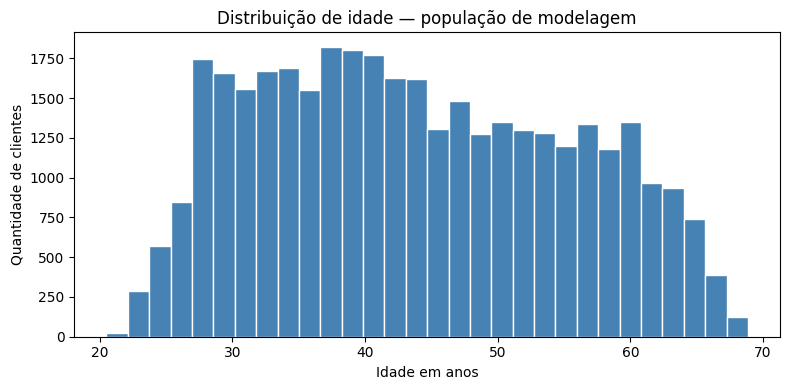

In [95]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    df_modelo["IDADE_ANOS"],
    bins=30,
    color="steelblue",
    edgecolor="white"
)

ax.set_title("Distribuição de idade — população de modelagem")
ax.set_xlabel("Idade em anos")
ax.set_ylabel("Quantidade de clientes")

plt.tight_layout()
plt.show()

A população de modelagem apresenta idades entre aproximadamente
20,5 e 68,9 anos. O histograma mostra frequências mais elevadas
em várias faixas entre o final dos 20 anos e meados dos 40 anos,
com menor quantidade de clientes nos extremos da distribuição.

Essa visualização descreve o perfil etário da população.
Isoladamente, ela não permite concluir quais idades estão
associadas à ocorrência de atraso.

#### Distribuição de renda

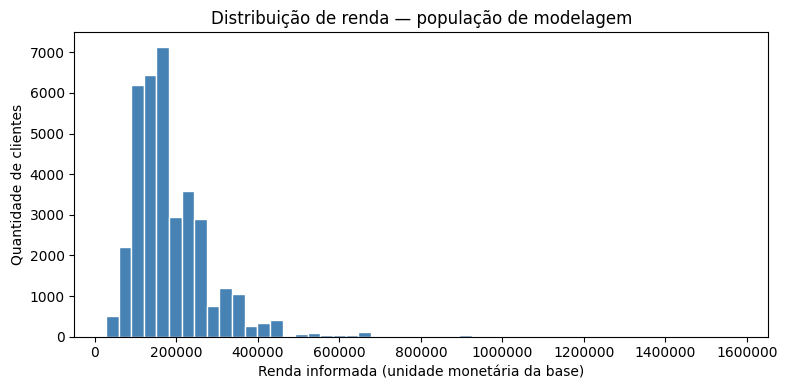

In [96]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    df_modelo["AMT_INCOME_TOTAL"],
    bins=50,
    color="steelblue",
    edgecolor="white"
)

ax.set_title("Distribuição de renda — população de modelagem")
ax.set_xlabel("Renda informada (unidade monetária da base)")
ax.set_ylabel("Quantidade de clientes")

ax.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()

A distribuição de renda apresenta assimetria à direita.
A maior parte dos clientes está concentrada nas faixas abaixo
de aproximadamente 300 mil, enquanto poucos registros apresentam
valores muito superiores, chegando a 1,575 milhão na unidade
monetária original da base.

Esses valores elevados ampliam a escala horizontal e dificultam
a visualização das faixas mais frequentes. Sua presença, por si só,
não comprova erro de preenchimento, e os registros foram mantidos.

O gráfico descreve a distribuição de renda da população de modelagem.
Isoladamente, não permite concluir que rendas maiores ou menores
estejam associadas à ocorrência de atraso.

#### Correlação entre variáveis numéricas

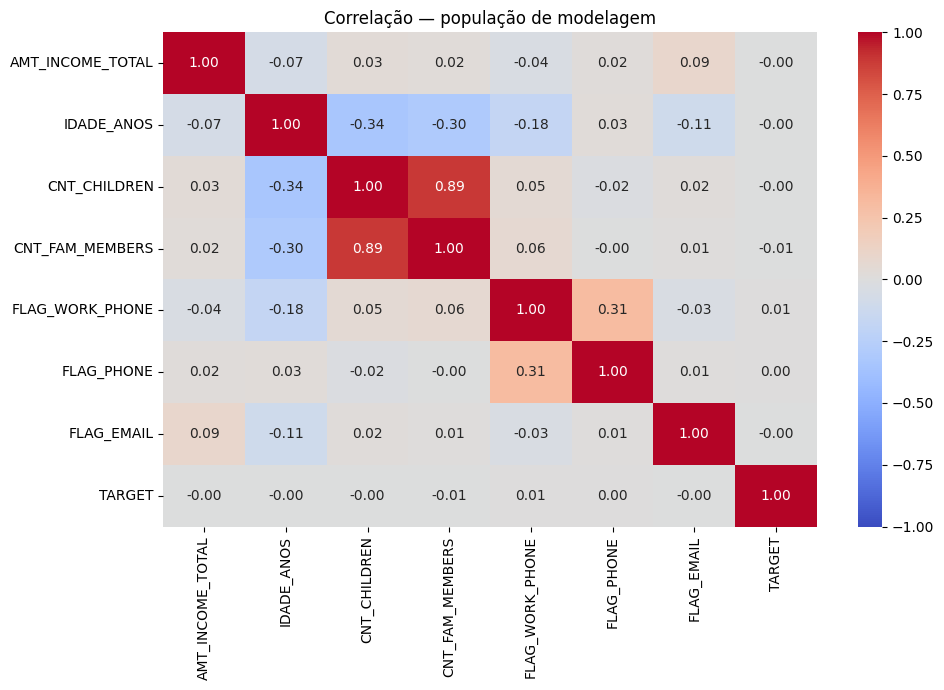

In [97]:
import seaborn as sns

variaveis_correlacao = [
    "AMT_INCOME_TOTAL",
    "IDADE_ANOS",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "FLAG_WORK_PHONE",
    "FLAG_PHONE",
    "FLAG_EMAIL",
    "TARGET"
]

correlacao = df_modelo[variaveis_correlacao].corr(
    method="pearson"
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    ax=ax
)

ax.set_title("Correlação — população de modelagem")

plt.tight_layout()
plt.show()

A maior correlação positiva foi observada entre quantidade de filhos
e membros da família (0,89). Essa associação é esperada, pois os filhos
fazem parte da composição familiar, indicando sobreposição parcial
de informação entre essas características.

A idade apresentou correlação negativa com quantidade de filhos
(-0,34) e membros da família (-0,30). Na população analisada,
clientes mais velhos tendem a apresentar valores menores nessas
variáveis, sem que isso estabeleça uma relação causal.

Os indicadores de telefone de trabalho e telefone apresentaram
correlação positiva de 0,31.

As correlações das variáveis selecionadas com o TARGET ficaram
próximas de zero. Isso indica pouca associação linear individual,
mas não descarta relações não lineares ou utilidade conjunta
na modelagem. Valores exibidos como 0,00 ou -0,00 podem representar
correlações pequenas arredondadas.

#### Distribuição da variável-alvo

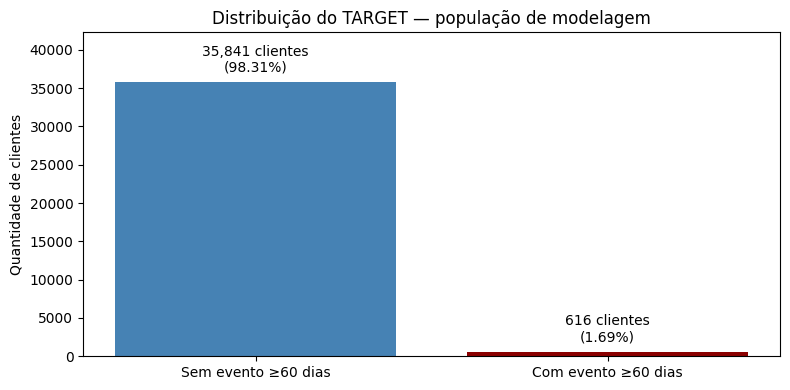

In [98]:
contagem_target = (
    df_modelo["TARGET"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

percentuais_target = contagem_target / contagem_target.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4))

barras = ax.bar(
    ["Sem evento ≥60 dias", "Com evento ≥60 dias"],
    contagem_target.to_numpy(),
    color=["steelblue", "darkred"]
)

rotulos = [
    f"{quantidade:,} clientes\n({percentual:.2f}%)"
    for quantidade, percentual in zip(
        contagem_target,
        percentuais_target
    )
]

ax.bar_label(barras, labels=rotulos, padding=5)

ax.set_title("Distribuição do TARGET — população de modelagem")
ax.set_ylabel("Quantidade de clientes")
ax.set_ylim(0, contagem_target.max() * 1.18)

plt.tight_layout()
plt.show()

A variável-alvo apresenta forte desbalanceamento: 35.841 clientes
(98,31%) não tiveram evento de atraso ≥60 dias observado,
enquanto 616 (1,69%) apresentaram pelo menos um evento.

Uma classificação que atribuísse classe 0 a todos os clientes
teria acurácia de 98,31% nessa população, mas não identificaria
nenhum caso positivo. Portanto, a acurácia isolada não é suficiente
para avaliar o desempenho.

A avaliação dos modelos priorizou Average Precision e foi
complementada por ROC AUC, precisão, recall, F1 e matriz de confusão.
Também foram investigados pesos de classes, sobreamostragem
aleatória e diferentes limiares de classificação.

## 9. Preparação das características cadastrais

### 9.1 Tempo de emprego

O valor especial 365243 em DAYS_EMPLOYED não foi interpretado
como uma duração válida de emprego.

Para preservar essa informação, foi criado um indicador de presença
do código especial. Esse indicador não representa, necessariamente,
uma condição de desemprego.

Os demais valores foram convertidos de dias negativos para uma duração
positiva em anos. Nos registros com o código especial, o tempo de emprego
foi considerado ausente, evitando atribuir uma duração sem fundamento.

Essas ausências foram tratadas posteriormente no pré-processamento,
com medianas calculadas apenas nos dados de treinamento.
A variável original foi preservada na base consolidada para conferência.

In [99]:
df_modelo["EMPREGO_CODIGO_ESPECIAL"] = (
    df_modelo["DAYS_EMPLOYED"].eq(365243).astype(int)
)

In [100]:
df_modelo[["DAYS_EMPLOYED", "EMPREGO_CODIGO_ESPECIAL"]].head(10)

,DAYS_EMPLOYED,EMPREGO_CODIGO_ESPECIAL
0,-4542,0
1,-4542,0
2,-1134,0
3,-3051,0
4,-3051,0
5,-3051,0
6,-3051,0
7,365243,1
8,365243,1
9,365243,1


In [101]:
df_modelo["TEMPO_EMPREGO_ANOS"] = (
    df_modelo["DAYS_EMPLOYED"]
    .mask(df_modelo["DAYS_EMPLOYED"].eq(365243))
    * -1
    / 365.25
)

In [102]:
df_modelo[
    ["DAYS_EMPLOYED", "EMPREGO_CODIGO_ESPECIAL", "TEMPO_EMPREGO_ANOS"]
].head(10)

,DAYS_EMPLOYED,EMPREGO_CODIGO_ESPECIAL,TEMPO_EMPREGO_ANOS
0,-4542,0,12.44
1,-4542,0,12.44
2,-1134,0,3.10
3,-3051,0,8.35
4,-3051,0,8.35
5,-3051,0,8.35
6,-3051,0,8.35
7,365243,1,NaN
8,365243,1,NaN
9,365243,1,NaN


In [103]:
df_modelo[["DAYS_BIRTH", "IDADE_ANOS"]].head()

,DAYS_BIRTH,IDADE_ANOS
0,-12005,32.87
1,-12005,32.87
2,-21474,58.79
3,-19110,52.32
4,-19110,52.32


### 9.2 Características e variável-alvo

A base foi separada em características cadastrais (X)
e variável-alvo TARGET (y).

Foram excluídos das características:

- TARGET, por representar a resposta a ser prevista;
- ID, por ser um identificador do cliente;
- DAYS_BIRTH, substituída pela idade em anos;
- DAYS_EMPLOYED, substituída pelo tempo de emprego em anos
  e pelo indicador do código especial.

O conjunto resultante contém 36.457 clientes e 18 características,
com uma resposta por cliente.

As informações do histórico mensal utilizadas para definir o TARGET
não foram incluídas como características dos modelos.

In [104]:
X = df_modelo.drop(
    columns=["TARGET", "ID", "DAYS_BIRTH", "DAYS_EMPLOYED"]
)

y = df_modelo["TARGET"].copy()

In [105]:
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (36457, 18)
Dimensão de y: (36457,)


## 10. Divisão entre treino e teste

A população foi inicialmente dividida por cliente em:

- treino: 29.165 clientes, aproximadamente 80%;
- teste: 7.292 clientes, aproximadamente 20%.

A divisão foi estratificada pela variável-alvo, preservando
aproximadamente a proporção das classes nos dois conjuntos.
Foi fixada uma semente aleatória para permitir sua reprodução
no mesmo ambiente.

O pré-processamento foi ajustado apenas nos dados de treinamento.

### Limitações da avaliação

Posteriormente, verificou-se que 89,08% dos clientes do teste
apresentam características iguais às de algum cliente do treino.
Essa sobreposição pode favorecer o desempenho, sem demonstrar
a mesma capacidade de generalização para perfis diferentes.

Por esse motivo, a seleção dos modelos utilizou validação cruzada
por grupos de perfis iguais dentro do treino. Também foi realizada
uma avaliação complementar nos 796 clientes do teste cujos perfis
não estavam presentes no treinamento.

Como o teste foi consultado durante o desenvolvimento,
seus resultados são apresentados como exploratórios,
e não como uma avaliação final totalmente independente.

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

In [107]:
print("X de treino:", X_train.shape)
print("X de teste:", X_test.shape)
print("y de treino:", y_train.shape)
print("y de teste:", y_test.shape)

X de treino: (29165, 18)
X de teste: (7292, 18)
y de treino: (29165,)
y de teste: (7292,)


## 11. Pré-processamento

As 18 características foram divididas em 10 numéricas e 8 categóricas,
com tratamentos específicos para cada grupo.

### Variáveis numéricas

Os valores ausentes foram preenchidos com a mediana de cada variável.
Essa escolha reduz a influência de valores extremos no preenchimento,
mas não recupera o valor real desconhecido.

As variáveis foram padronizadas para tornar suas escalas comparáveis.
Esse tratamento é relevante para a regressão logística.
Também foi mantido nos modelos de árvores por conveniência da estrutura
compartilhada, embora eles não exijam padronização.

### Variáveis categóricas

Os valores ausentes foram preenchidos com a categoria "Nao_informado",
preservando a ausência de informação sem atribuir uma categoria desconhecida
ao cliente.

As categorias foram representadas por indicadores binários
(One-Hot Encoding), sem estabelecer uma ordem artificial entre elas.

### Prevenção de vazamento de informação

O pré-processamento foi integrado aos modelos por meio de pipelines.
As medianas, os parâmetros de padronização e as categorias foram aprendidos
somente com os dados utilizados para treinamento.

Na validação cruzada, o pré-processamento foi ajustado separadamente
em cada rodada, sem utilizar a parte reservada para validação.
No teste, foram aplicadas as transformações aprendidas no treino.

In [108]:
colunas_numericas = (
    X_train.select_dtypes(include="number").columns.tolist()
)

colunas_categoricas = (
    X_train.select_dtypes(exclude="number").columns.tolist()
)



In [109]:
print("Numéricas:", colunas_numericas)
print("Categóricas:", colunas_categoricas)

Numéricas: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'IDADE_ANOS', 'EMPREGO_CODIGO_ESPECIAL', 'TEMPO_EMPREGO_ANOS']
Categóricas: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


In [110]:
from sklearn.impute import SimpleImputer

imputador_numerico = SimpleImputer(strategy="median")

In [111]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline_numerico = Pipeline([
    ("imputacao", imputador_numerico),
    ("escala", StandardScaler())
])

In [112]:
imputador_categorico = SimpleImputer(
    strategy="constant",
    fill_value="Nao_informado"
)

In [113]:
from sklearn.preprocessing import OneHotEncoder

pipeline_categorico = Pipeline([
    ("imputacao", imputador_categorico),
    ("codificacao", OneHotEncoder(handle_unknown="ignore"))
])

In [114]:
from sklearn.compose import ColumnTransformer

preprocessador = ColumnTransformer([
    ("numericas", pipeline_numerico, colunas_numericas),
    ("categoricas", pipeline_categorico, colunas_categoricas)
])

## 12. Modelagem supervisionada

### 12.1 Regressão logística — modelo de referência

A regressão logística foi utilizada como referência inicial para
avaliar a associação entre características cadastrais e a ocorrência
de atraso ≥60 dias no histórico disponível.

O modelo produz uma pontuação para a classe positiva, posteriormente
convertida em uma classificação por meio de um limiar de decisão.

Na configuração inicial, foram utilizados pesos inversamente
proporcionais às frequências das classes, devido à baixa proporção
de clientes com TARGET = 1. Essa ponderação aumenta a influência
da classe minoritária no treinamento, sem alterar a quantidade de clientes.

O pré-processamento e o modelo foram integrados em uma pipeline,
ajustada no conjunto de treino.

### Avaliação inicial

Com o limiar padrão de 0,50, o modelo identificou 59 dos 123 casos
positivos do teste, mas gerou 2.728 falsos positivos:

- precisão da classe positiva: 2,12%;
- recall da classe positiva: 47,97%;
- F1 da classe positiva: 0,0405;
- Average Precision: 0,0634.

A Average Precision superou a proporção de positivos do teste,
de aproximadamente 0,0169, mas a classificação apresentou
baixa precisão.

Esses resultados constituem uma referência exploratória.
A configuração inicial foi posteriormente comparada com outros
modelos e revista por validação cruzada no treino.

In [115]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

In [116]:
modelo_logistico.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputacao',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escala',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'IDADE_ANOS',
                                                   'EMPREGO_CODIGO_ESPECIAL',
                                                   'TEMPO_EMPREGO_ANOS']),
                                                 ('ca...
                                                  Pipeline(steps=[('imputacao',
                                                                   SimpleImputer(fill_value='Nao_informado',
                                                                                 strategy='constant')),
                                                                  ('codificacao',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('modelo',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [117]:
y_pred_logistico = modelo_logistico.predict(X_test)

In [118]:
y_pred_logistico[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [119]:
from sklearn.metrics import confusion_matrix

matriz_logistico = confusion_matrix(
    y_test,
    y_pred_logistico,
    labels=[0, 1]
)

pd.DataFrame(
    matriz_logistico,
    index=["Real 0", "Real 1"],
    columns=["Previsto 0", "Previsto 1"]
)

,Previsto 0,Previsto 1
Real 0,4441,2728
Real 1,64,59


In [120]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_logistico,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

           0     0.9858    0.6195    0.7608      7169
           1     0.0212    0.4797    0.0405       123

    accuracy                         0.6171      7292
   macro avg     0.5035    0.5496    0.4007      7292
weighted avg     0.9695    0.6171    0.7487      7292



In [121]:
y_prob_logistico = modelo_logistico.predict_proba(X_test)[:, 1]

y_prob_logistico[:10]

array([0.4559348 , 0.32968759, 0.48824931, 0.47966287, 0.47394362,
       0.26717235, 0.42094548, 0.56648997, 0.33616103, 0.37613592])

In [122]:
from sklearn.metrics import average_precision_score

ap_logistico = average_precision_score(
    y_test,
    y_prob_logistico
)

print(f"Average Precision: {ap_logistico:.4f}")
print(f"Proporção de positivos no teste: {y_test.mean():.4f}")

Average Precision: 0.0634
Proporção de positivos no teste: 0.0169


### 12.2 Comparação inicial dos modelos

Foram avaliadas quatro abordagens de classificação:

- regressão logística: modelo de referência;
- árvore de decisão: regras de divisão das características;
- Random Forest: combinação de múltiplas árvores;
- Gradient Boosting: árvores construídas sequencialmente.

As configurações iniciais foram comparadas por validação cruzada
estratificada com cinco divisões do conjunto de treino.
O pré-processamento foi ajustado separadamente em cada rodada.

A Average Precision (AP) foi utilizada como métrica principal
de comparação devido à baixa frequência da classe positiva.
Ela resume a relação entre precisão e recall ao variar o limiar
e não representa o percentual de classificações corretas.

| Modelo | AP média | Desvio-padrão |
|---|---:|---:|
| Regressão logística | 0,0595 | 0,0123 |
| Árvore de decisão | 0,0262 | 0,0040 |
| Random Forest | 0,1938 | 0,0289 |
| Gradient Boosting | 0,0963 | 0,0369 |

A Random Forest apresentou a maior AP média nessa avaliação.
Entretanto, as divisões foram realizadas por cliente, permitindo
que perfis cadastrais iguais aparecessem no treinamento
e na validação.

Por isso, esses resultados foram considerados uma comparação
inicial e complementados pela validação por grupos de perfis.

In [123]:
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier

modelo_arvore = Pipeline([
    ("preprocessamento", clone(preprocessador)),
    ("modelo", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

In [124]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

ap_cv_arvore = cross_val_score(
    modelo_arvore,
    X_train,
    y_train,
    cv=cv,
    scoring="average_precision"
)

In [125]:
print("AP por rodada:", ap_cv_arvore)
print(f"AP média: {ap_cv_arvore.mean():.4f}")
print(f"Desvio-padrão: {ap_cv_arvore.std():.4f}")

AP por rodada: [0.02589423 0.02262868 0.03389731 0.02355959 0.02514512]
AP média: 0.0262
Desvio-padrão: 0.0040


In [126]:
ap_cv_logistico = cross_val_score(
    modelo_logistico,
    X_train,
    y_train,
    cv=cv,
    scoring="average_precision"
)


In [127]:
print("AP por rodada:", ap_cv_logistico)
print(f"AP média: {ap_cv_logistico.mean():.4f}")
print(f"Desvio-padrão: {ap_cv_logistico.std():.4f}")

AP por rodada: [0.04181    0.05706238 0.05547836 0.07969601 0.06353294]
AP média: 0.0595
Desvio-padrão: 0.0123


In [128]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline([
    ("preprocessamento", clone(preprocessador)),
    ("modelo", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

ap_cv_rf = cross_val_score(
    modelo_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="average_precision"
)

In [129]:
print("AP por rodada:", ap_cv_rf)
print(f"AP média: {ap_cv_rf.mean():.4f}")
print(f"Desvio-padrão: {ap_cv_rf.std():.4f}")

AP por rodada: [0.17727454 0.22840518 0.14867705 0.19493171 0.21992394]
AP média: 0.1938
Desvio-padrão: 0.0289


In [130]:
from sklearn.ensemble import GradientBoostingClassifier

modelo_gb = Pipeline([
    ("preprocessamento", clone(preprocessador)),
    ("modelo", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ))
])

ap_cv_gb = cross_val_score(
    modelo_gb,
    X_train,
    y_train,
    cv=cv,
    scoring="average_precision"
)


In [131]:
print("AP por rodada:", ap_cv_gb)
print(f"AP média: {ap_cv_gb.mean():.4f}")
print(f"Desvio-padrão: {ap_cv_gb.std():.4f}")

AP por rodada: [0.05792922 0.11334535 0.08013184 0.16024845 0.06970916]
AP média: 0.0963
Desvio-padrão: 0.0369


### 12.3 Validação por grupos de perfis cadastrais

Os 29.165 clientes do treino correspondem a 9.028 combinações
distintas das características utilizadas na modelagem.

Perfis iguais com IDs diferentes não foram excluídos, pois essa
semelhança não comprova que os registros pertençam à mesma pessoa.
Mas sua presença nos dois lados de uma divisão pode favorecer
o desempenho sem demonstrar generalização para perfis diferentes.

Foi realizada validação cruzada com cinco divisões por grupos,
mantendo os clientes de cada perfil na mesma parte.
A proporção das classes foi aproximada, respeitando essa restrição.

| Modelo | AP média | Desvio-padrão |
|---|---:|---:|
| Regressão logística | 0,0585 | 0,0409 |
| Gradient Boosting | 0,0456 | 0,0138 |
| Random Forest | 0,0434 | 0,0152 |
| Árvore de decisão | 0,0208 | 0,0057 |

A AP média da Random Forest caiu de 0,1938 na validação por clientes
para 0,0434 na validação por grupos. Essa diferença sugere que
o compartilhamento de perfis favorecia o resultado inicial.

A regressão logística apresentou a maior AP média por grupos,
mas também maior variação entre rodadas. Portanto, sua vantagem
não foi interpretada como superioridade estatística comprovada.

A validação por grupos foi adotada para orientar a seleção
e o ajuste do modelo. Todos os clientes do treino foram preservados.
Os valores apresentados correspondem à execução no ambiente
documentado do Colab.

In [132]:
grupos_perfil = (
    X_train
    .groupby(
        X_train.columns.tolist(),
        dropna=False,
        sort=False
    )
    .ngroup()
)

In [133]:
print("Clientes no treino:", len(X_train))
print("Perfis distintos:", grupos_perfil.nunique())

Clientes no treino: 29165
Perfis distintos: 9028


In [134]:
from sklearn.model_selection import StratifiedGroupKFold

cv_grupos = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

ap_cv_rf_grupos = cross_val_score(
    modelo_rf,
    X_train,
    y_train,
    groups=grupos_perfil,
    cv=cv_grupos,
    scoring="average_precision"
)


In [135]:
print("AP por rodada:", ap_cv_rf_grupos)
print(f"AP média por grupos: {ap_cv_rf_grupos.mean():.4f}")
print(f"Desvio-padrão: {ap_cv_rf_grupos.std():.4f}")

AP por rodada: [0.02833024 0.05902455 0.06278627 0.02591077 0.04079398]
AP média por grupos: 0.0434
Desvio-padrão: 0.0152


In [136]:
resultados_grupos = [{
    "modelo": "Random Forest",
    "AP_media": ap_cv_rf_grupos.mean(),
    "AP_desvio": ap_cv_rf_grupos.std()
}]

for nome, modelo in [
    ("Regressão logística", modelo_logistico),
    ("Árvore de decisão", modelo_arvore),
    ("Gradient Boosting", modelo_gb)
]:
    scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        groups=grupos_perfil,
        cv=cv_grupos,
        scoring="average_precision"
    )

    resultados_grupos.append({
        "modelo": nome,
        "AP_media": scores.mean(),
        "AP_desvio": scores.std()
    })

comparacao_grupos = (
    pd.DataFrame(resultados_grupos)
    .sort_values("AP_media", ascending=False)
)

comparacao_grupos

,modelo,AP_media,AP_desvio
1,Regressão logística,0.06,0.04
3,Gradient Boosting,0.05,0.01
0,Random Forest,0.04,0.02
2,Árvore de decisão,0.02,0.01


In [137]:
comparacao_grupos.style.format({
    "AP_media": "{:.4f}",
    "AP_desvio": "{:.4f}"
})

,modelo,AP_media,AP_desvio
1,Regressão logística,0.0585,0.0409
3,Gradient Boosting,0.0456,0.0138
0,Random Forest,0.0434,0.0152
2,Árvore de decisão,0.0208,0.0057


### 12.4 Ajuste de hiperparâmetros da regressão logística

A regressão logística foi selecionada para uma busca limitada
de hiperparâmetros, por apresentar a maior AP média na comparação
inicial por grupos.

Foram avaliadas seis combinações:

- intensidade de regularização: C = 0,01, 0,1 e 1,0;
- pesos das classes: naturais ou balanceados.

Valores menores de C impõem maior regularização,
restringindo a intensidade dos coeficientes.

A busca utilizou as mesmas cinco divisões por grupos do treino
e a Average Precision como critério de seleção.
O teste não foi utilizado para escolher esses parâmetros.

A configuração selecionada foi C = 1,0, sem balanceamento,
com AP média de 0,0767.

| Rodada | AP |
|---|---:|
| 1 | 0,0255 |
| 2 | 0,0474 |
| 3 | 0,0623 |
| 4 | 0,0761 |
| 5 | 0,1722 |

A média foi influenciada pelo resultado mais elevado da quinta
rodada, indicando variação relevante entre os grupos avaliados.

Essa pontuação foi utilizada para selecionar a configuração
e não constitui uma estimativa independente de desempenho.
Após a seleção, o modelo foi ajustado em todo o conjunto de treino.

In [138]:
from sklearn.model_selection import GridSearchCV

parametros_logistico = {
    "modelo__C": [0.01, 0.1, 1.0],
    "modelo__class_weight": [None, "balanced"]
}

busca_logistico = GridSearchCV(
    estimator=clone(modelo_logistico),
    param_grid=parametros_logistico,
    scoring="average_precision",
    cv=cv_grupos,
    refit=True
)

busca_logistico.fit(
    X_train,
    y_train,
    groups=grupos_perfil
)

GridSearchCV(cv=StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessamento',
                                        ColumnTransformer(transformers=[('numericas',
                                                                         Pipeline(steps=[('imputacao',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('escala',
                                                                                          StandardScaler())]),
                                                                         ['CNT_CHILDREN',
                                                                          'AMT_INCOME_TOTAL',
                                                                          'FLAG_MOBIL',
                                                                          'FLAG_WORK_PHONE',
                                                                          'FLAG_PHONE',
                                                                          'FLAG_EMA...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['CODE_GENDER',
                                                                          'FLAG_OWN_CAR',
                                                                          'FLAG_OWN_REALTY',
                                                                          'NAME_INCOME_TYPE',
                                                                          'NAME_EDUCATION_TYPE',
                                                                          'NAME_FAMILY_STATUS',
                                                                          'NAME_HOUSING_TYPE',
                                                                          'OCCUPATION_TYPE'])])),
                                       ('modelo',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000))]),
             param_grid={'modelo__C': [0.01, 0.1, 1.0],
                         'modelo__class_weight': [None, 'balanced']},
             scoring='average_precision')

In [139]:
print("Melhores parâmetros:", busca_logistico.best_params_)
print(f"Melhor AP média: {busca_logistico.best_score_:.4f}")

Melhores parâmetros: {'modelo__C': 1.0, 'modelo__class_weight': None}
Melhor AP média: 0.0767


In [140]:
indice_melhor = busca_logistico.best_index_

ap_melhor_logistico = [
    busca_logistico.cv_results_[f"split{i}_test_score"][indice_melhor]
    for i in range(5)
]


In [141]:
print("AP por rodada:", ap_melhor_logistico)

AP por rodada: [np.float64(0.025538987854393343), np.float64(0.047443356097691215), np.float64(0.06234718882392935), np.float64(0.07611149942946956), np.float64(0.17223787981092295)]


### 12.5 Avaliação exploratória no teste

Foi verificado que 6.496 dos 7.292 clientes do teste (89,08%)
possuem perfis iguais aos de algum cliente do treino.

A configuração selecionada foi avaliada no teste completo
e, complementarmente, nos 796 clientes com perfis ausentes
do treinamento. Esse subconjunto contém 45 casos positivos.

| Avaliação | Clientes | Positivos | Proporção positiva | ROC AUC | AP |
|---|---:|---:|---:|---:|---:|
| Teste completo | 7.292 | 123 | 1,69% | 0,5682 | 0,0857 |
| Perfis ausentes do treino | 796 | 45 | 5,65% | 0,5665 | 0,2351 |

A ROC AUC indica separação global fraca nas duas avaliações.
A AP supera a proporção de positivos de cada conjunto, sugerindo
concentração de alguns eventos nas maiores pontuações.

As APs não devem ser comparadas isoladamente, pois os conjuntos
possuem populações e proporções de positivos diferentes.

Com o limiar padrão de 0,50, o modelo identificou apenas três
casos positivos no teste completo, sem falsos positivos.
O recall foi de 2,44%, apesar da acurácia de 98,35%.

Esses resultados mostram que a acurácia elevada decorre principalmente
do acerto na classe majoritária e não de boa identificação dos atrasos.

O subconjunto de perfis novos constitui uma análise complementar,
não um teste independente planejado previamente.
Como o teste foi consultado durante o desenvolvimento,
todas essas avaliações são apresentadas como exploratórias.

In [142]:
X_conjunto = pd.concat([X_train, X_test])

grupos_conjunto = (
    X_conjunto
    .groupby(
        X_conjunto.columns.tolist(),
        dropna=False,
        sort=False
    )
    .ngroup()
)

grupos_treino = grupos_conjunto.loc[X_train.index]
grupos_teste = grupos_conjunto.loc[X_test.index]

perfil_compartilhado = grupos_teste.isin(grupos_treino)

In [143]:
print("Clientes no teste:", len(X_test))
print("Clientes com perfil presente no treino:", perfil_compartilhado.sum())
print(f"Percentual: {perfil_compartilhado.mean():.2%}")

Clientes no teste: 7292
Clientes com perfil presente no treino: 6496
Percentual: 89.08%


In [144]:
X_test_perfis_novos = X_test.loc[~perfil_compartilhado].copy()
y_test_perfis_novos = y_test.loc[~perfil_compartilhado].copy()

print("Clientes com perfis novos:", len(X_test_perfis_novos))
print(y_test_perfis_novos.value_counts().sort_index())

Clientes com perfis novos: 796
TARGET
0    751
1     45
Name: count, dtype: int64


In [145]:
from sklearn.metrics import roc_auc_score

modelo_selecionado = busca_logistico.best_estimator_

pred_novos = modelo_selecionado.predict(X_test_perfis_novos)
prob_novos = modelo_selecionado.predict_proba(
    X_test_perfis_novos
)[:, 1]



In [146]:
print(classification_report(
    y_test_perfis_novos,
    pred_novos,
    digits=4,
    zero_division=0
))

print(
    "ROC AUC:",
    round(roc_auc_score(y_test_perfis_novos, prob_novos), 4)
)

print(
    "Average Precision:",
    round(average_precision_score(y_test_perfis_novos, prob_novos), 4)
)

print(
    "Proporção de positivos:",
    round(y_test_perfis_novos.mean(), 4)
)

              precision    recall  f1-score   support

           0     0.9470    1.0000    0.9728       751
           1     1.0000    0.0667    0.1250        45

    accuracy                         0.9472       796
   macro avg     0.9735    0.5333    0.5489       796
weighted avg     0.9500    0.9472    0.9249       796

ROC AUC: 0.5665
Average Precision: 0.2351
Proporção de positivos: 0.0565


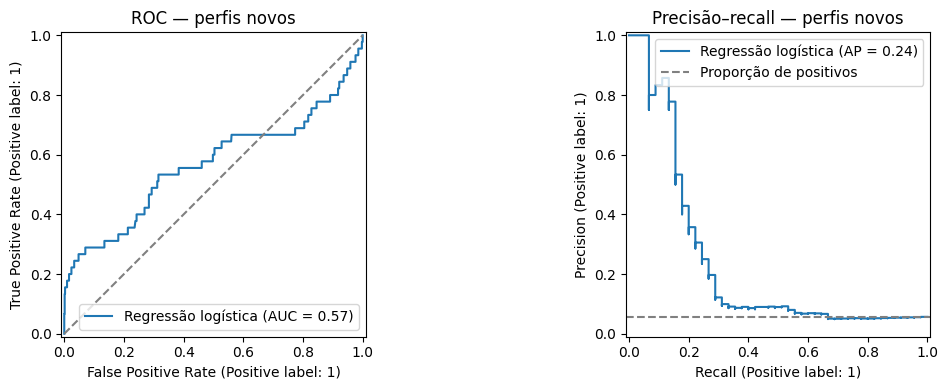

In [147]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(
    y_test_perfis_novos,
    prob_novos,
    ax=axes[0],
    name="Regressão logística"
)

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC — perfis novos")

PrecisionRecallDisplay.from_predictions(
    y_test_perfis_novos,
    prob_novos,
    ax=axes[1],
    name="Regressão logística"
)

axes[1].axhline(
    y_test_perfis_novos.mean(),
    linestyle="--",
    color="gray",
    label="Proporção de positivos"
)

axes[1].set_title("Precisão–recall — perfis novos")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Interpretação — desempenho em perfis cadastrais novos

As curvas ROC e Precisão–Recall apresentam o desempenho da regressão logística no subconjunto de teste composto por perfis cadastrais não encontrados no treinamento.

A curva ROC permite observar a capacidade de discriminação entre as classes, enquanto a curva Precisão–Recall é especialmente relevante diante da baixa proporção de clientes com atraso ≥ 60 dias.

Esses resultados devem ser interpretados considerando o desbalanceamento da variável-alvo e a quantidade limitada de casos positivos. A avaliação em perfis novos também ajuda a investigar a capacidade de generalização do modelo, sem eliminar as demais limitações metodológicas identificadas no estudo.

In [148]:
pred_teste_final = modelo_selecionado.predict(X_test)
prob_teste_final = modelo_selecionado.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    pred_teste_final,
    digits=4,
    zero_division=0
))

print(f"ROC AUC: {roc_auc_score(y_test, prob_teste_final):.4f}")
print(
    f"Average Precision: "
    f"{average_precision_score(y_test, prob_teste_final):.4f}"
)


              precision    recall  f1-score   support

           0     0.9835    1.0000    0.9917      7169
           1     1.0000    0.0244    0.0476       123

    accuracy                         0.9835      7292
   macro avg     0.9918    0.5122    0.5197      7292
weighted avg     0.9838    0.9835    0.9758      7292

ROC AUC: 0.5682
Average Precision: 0.0857


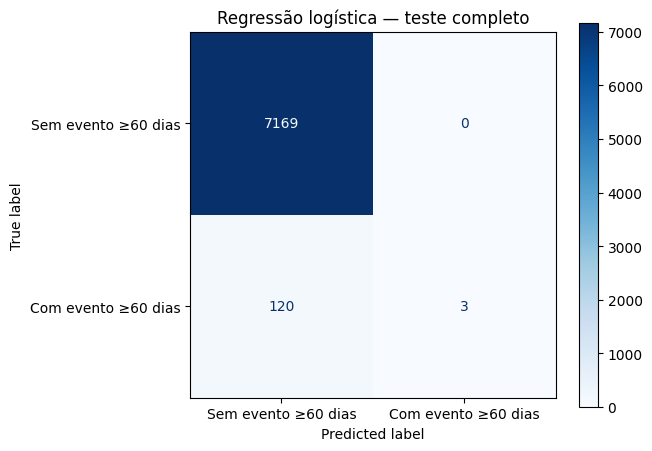

In [149]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_teste_final,
    labels=[0, 1],
    display_labels=["Sem evento ≥60 dias", "Com evento ≥60 dias"],
    cmap="Blues",
    values_format="d"
)

plt.title("Regressão logística — teste completo")
plt.tight_layout()
plt.show()

### 12.6 Análise do limiar de classificação

O limiar determina a partir de qual pontuação um cliente recebe
a previsão de classe 1. Alterar ele modifica as decisões, mas não
a ordenação das pontuações nem a definição do TARGET.

Foram produzidas previsões fora da amostra para os clientes do treino,
com separação por grupos de perfis. Cada pontuação foi obtida por
um modelo treinado sem o grupo do cliente avaliado.

Como os hiperparâmetros foram selecionados nas mesmas divisões,
essa análise integra o ajuste do modelo e não representa
uma avaliação independente.

Foram comparados os limiares 0,01, 0,02, 0,03, 0,05, 0,10 e 0,50.
O corte de 0,05 apresentou o maior F1 entre os valores testados
e foi registrado como cenário alternativo exploratório.

| Resultado no teste completo | Limiar 0,50 | Limiar 0,05 |
|---|---:|---:|
| Atrasos identificados | 3 | 10 |
| Falsos positivos | 0 | 45 |
| Atrasos não identificados | 120 | 113 |
| Precisão da classe positiva | 100% | 18,18% |
| Recall da classe positiva | 2,44% | 8,13% |
| F1 da classe positiva | 0,0476 | 0,1124 |

A redução do limiar aumentou a identificação de atrasos,
com aumento dos falsos positivos. Ainda assim, a maioria
dos eventos permaneceu sem identificação.

O corte de 0,05 não foi demonstrado como ótimo e não constitui
uma regra de aprovação de crédito. Uma decisão operacional
exigiria considerar os custos dos erros e a capacidade de análise.

ROC AUC e Average Precision permanecem inalteradas,
pois as pontuações utilizadas são as mesmas.

In [150]:
from sklearn.model_selection import cross_val_predict

prob_oof = cross_val_predict(
    clone(modelo_selecionado),
    X_train,
    y_train,
    groups=grupos_perfil,
    cv=cv_grupos,
    method="predict_proba"
)[:, 1]

print("Quantidade de pontuações:", len(prob_oof))
print("Primeiras pontuações:", prob_oof[:10])

Quantidade de pontuações: 29165
Primeiras pontuações: [0.0128133  0.02275952 0.00763619 0.00752944 0.01050665 0.01053424
 0.02093983 0.03387189 0.03235422 0.01440424]


In [151]:
from sklearn.metrics import precision_score, recall_score, f1_score

resultados_limiares = []

for limiar in [0.01, 0.02, 0.03, 0.05, 0.10, 0.50]:
    pred_oof = (prob_oof >= limiar).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        pred_oof,
        labels=[0, 1]
    ).ravel()

    resultados_limiares.append({
        "limiar": limiar,
        "precisao": precision_score(y_train, pred_oof, zero_division=0),
        "recall": recall_score(y_train, pred_oof, zero_division=0),
        "F1": f1_score(y_train, pred_oof, zero_division=0),
        "atrasos_identificados": tp,
        "falsos_positivos": fp,
        "atrasos_nao_identificados": fn
    })

tabela_limiares = pd.DataFrame(resultados_limiares)

tabela_limiares.style.format({
    "limiar": "{:.2f}",
    "precisao": "{:.2%}",
    "recall": "{:.2%}",
    "F1": "{:.4f}"
})

,limiar,precisao,recall,F1,atrasos_identificados,falsos_positivos,atrasos_nao_identificados
0,0.01,1.74%,82.76%,0.0340,408,23103,85
1,0.02,2.16%,34.28%,0.0407,169,7640,324
2,0.03,3.49%,14.81%,0.0565,73,2018,420
3,0.05,18.02%,6.29%,0.0932,31,141,462
4,0.10,85.00%,3.45%,0.0663,17,3,476
5,0.50,100.00%,1.01%,0.0201,5,0,488


In [152]:
limiar_alternativo = 0.05

pred_teste_alternativo = (
    prob_teste_final >= limiar_alternativo
).astype(int)

print(classification_report(
    y_test,
    pred_teste_alternativo,
    digits=4,
    zero_division=0
))

pd.DataFrame(
    confusion_matrix(y_test, pred_teste_alternativo, labels=[0, 1]),
    index=["Real 0", "Real 1"],
    columns=["Previsto 0", "Previsto 1"]
)


              precision    recall  f1-score   support

           0     0.9844    0.9937    0.9890      7169
           1     0.1818    0.0813    0.1124       123

    accuracy                         0.9783      7292
   macro avg     0.5831    0.5375    0.5507      7292
weighted avg     0.9708    0.9783    0.9742      7292



,Previsto 0,Previsto 1
Real 0,7124,45
Real 1,113,10


### 12.7 Interpretação do modelo

A interpretação da regressão logística foi realizada por meio
dos coeficientes e da importância por permutação.

### Coeficientes

Coeficientes positivos contribuem para aumentar a pontuação
da classe positiva; negativos contribuem para reduzi-la,
considerando as demais características do modelo.

Nas variáveis numéricas padronizadas, os coeficientes se referem
a uma variação de um desvio-padrão. Nas categóricas, foram mantidos
todos os indicadores, sem uma categoria de referência explícita.

Os coeficientes não representam efeitos causais e sua magnitude
não equivale, isoladamente, à importância de uma característica.

Foi observada forte sobreposição entre o tipo de renda Pensioner
e o indicador do código especial de emprego: 4.889 dos 4.903
pensionistas do treino (99,71%) apresentavam esse código.

Essa relação permite que os coeficientes distribuam ou compensem
seus efeitos, limitando a interpretação individual dessas variáveis.

### Importância por permutação

A importância por permutação foi calculada no subconjunto
de 796 clientes com perfis ausentes do treino, utilizando a queda
de Average Precision após embaralhar cada característica.

As maiores quedas foram observadas para tipo de renda,
quantidade de membros da família, indicador do código especial
de emprego, quantidade de filhos e estado civil.

Esses resultados descrevem a dependência do modelo em relação
às características nesse subconjunto, não sua contribuição causal
para o atraso. As importâncias não devem ser somadas.

O embaralhamento individual pode criar combinações pouco plausíveis
entre variáveis relacionadas. Além disso, a avaliação contém
apenas 45 casos positivos, exigindo cautela na interpretação.

In [153]:
nomes_variaveis = (
    modelo_selecionado
    .named_steps["preprocessamento"]
    .get_feature_names_out()
)

coeficientes = (
    modelo_selecionado
    .named_steps["modelo"]
    .coef_
    .ravel()
)

tabela_coeficientes = pd.DataFrame({
    "variavel": nomes_variaveis,
    "coeficiente": coeficientes
})

tabela_coeficientes["magnitude"] = (
    tabela_coeficientes["coeficiente"].abs()
)

tabela_coeficientes = tabela_coeficientes.sort_values(
    "magnitude",
    ascending=False
)

tabela_coeficientes.head(15).style.format({
    "coeficiente": "{:.4f}",
    "magnitude": "{:.4f}"
})

,variavel,coeficiente,magnitude
17,categoricas__NAME_INCOME_TYPE_Pensioner,3.4392,3.4392
8,numericas__EMPREGO_CODIGO_ESPECIAL,-1.7182,1.7182
18,categoricas__NAME_INCOME_TYPE_State servant,-1.6761,1.6761
20,categoricas__NAME_INCOME_TYPE_Working,-1.3387,1.3387
16,categoricas__NAME_INCOME_TYPE_Commercial associate,-1.2114,1.2114
35,categoricas__NAME_HOUSING_TYPE_Rented apartment,-1.1884,1.1884
6,numericas__CNT_FAM_MEMBERS,1.1260,1.1260
27,categoricas__NAME_FAMILY_STATUS_Married,-1.0938,1.0938
26,categoricas__NAME_FAMILY_STATUS_Civil marriage,-1.0305,1.0305
50,categoricas__OCCUPATION_TYPE_Private service staff,-0.9079,0.9079


In [154]:
pd.crosstab(
    X_train["NAME_INCOME_TYPE"],
    X_train["EMPREGO_CODIGO_ESPECIAL"]
)

EMPREGO_CODIGO_ESPECIAL,0,1
NAME_INCOME_TYPE,,
Commercial associate,6795,0
Pensioner,14,4889
State servant,2399,0
Student,7,0
Working,15061,0


In [155]:
from sklearn.inspection import permutation_importance

importancia_perm = permutation_importance(
    modelo_selecionado,
    X_test_perfis_novos,
    y_test_perfis_novos,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE
)

tabela_importancia = pd.DataFrame({
    "variavel": X_test_perfis_novos.columns,
    "queda_AP_media": importancia_perm.importances_mean,
    "desvio": importancia_perm.importances_std
}).sort_values("queda_AP_media", ascending=False)

tabela_importancia.head(10).style.format({
    "queda_AP_media": "{:.4f}",
    "desvio": "{:.4f}"
})

,variavel,queda_AP_media,desvio
5,NAME_INCOME_TYPE,0.1589,0.0154
14,CNT_FAM_MEMBERS,0.1385,0.0177
16,EMPREGO_CODIGO_ESPECIAL,0.1210,0.0151
3,CNT_CHILDREN,0.1068,0.0119
7,NAME_FAMILY_STATUS,0.1046,0.0086
2,FLAG_OWN_REALTY,0.0204,0.0081
8,NAME_HOUSING_TYPE,0.0122,0.0113
0,CODE_GENDER,0.0094,0.0069
13,OCCUPATION_TYPE,0.0044,0.0122
1,FLAG_OWN_CAR,0.0006,0.0062


## 13. Aprendizado não supervisionado — clusterização

A clusterização foi utilizada para identificar perfis semelhantes,
sem fornecer o TARGET ao algoritmo.

Foram selecionadas quatro características: idade, renda,
quantidade de filhos e quantidade de membros da família.
A renda recebeu transformação logarítmica para reduzir a influência
de valores elevados, e as quatro características foram padronizadas.

O pré-processamento e o K-Means foram ajustados somente no treino.
Foram comparadas segmentações de dois a seis grupos, utilizando
inércia e silhouette, esta última estimada em uma amostra
reproduzível de 3.000 clientes.

A segmentação com dois grupos apresentou a maior silhouette
entre as opções avaliadas (0,3937) e foi adotada para interpretação.
Esse resultado não comprova a existência de exatamente dois
grupos naturais na população.

### Perfis encontrados no treino

| Característica | Grupo 0 | Grupo 1 |
|---|---:|---:|
| Clientes | 20.718 | 8.447 |
| Idade média | 46,6 | 36,6 |
| Renda mediana | 157.500 | 171.000 |
| Média de filhos | 0,03 | 1,42 |
| Média de membros da família | 1,73 | 3,35 |

Os grupos se diferenciam principalmente pela idade e pela composição
familiar. A renda está expressa na unidade monetária original da base.

Como quantidade de filhos e membros da família são relacionadas,
a composição familiar pode ter recebido peso reforçado
no cálculo das distâncias.

### Relação descritiva com o atraso

Após a formação dos grupos, foi consultada a frequência do TARGET.
Os clientes do teste foram atribuídos aos centros aprendidos no treino,
sem novo ajuste.

| Frequência de TARGET = 1 | Grupo 0 | Grupo 1 |
|---|---:|---:|
| Treino | 1,67% | 1,73% |
| Teste | 1,77% | 1,47% |

As frequências são próximas e sua ordem se inverte entre treino
e teste. Portanto, a segmentação descreve perfis demográficos
e familiares, mas não demonstra separação consistente de atraso.

Os identificadores dos grupos não representam classes de risco.
A comparação no teste também está sujeita à sobreposição
de perfis cadastrais já identificada.

In [156]:
colunas_cluster = [
    "IDADE_ANOS",
    "AMT_INCOME_TOTAL",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

X_cluster_train = X_train[colunas_cluster].copy()

X_cluster_train.head()

,IDADE_ANOS,AMT_INCOME_TOTAL,CNT_CHILDREN,CNT_FAM_MEMBERS
5155,64.18,"135,000.00",0,2.00
229,28.10,"270,000.00",0,2.00
17709,44.57,"180,000.00",0,2.00
10802,41.17,"225,000.00",1,2.00
15990,46.94,"180,000.00",0,2.00


In [157]:
import numpy as np

X_cluster_preparacao = X_cluster_train.copy()

X_cluster_preparacao["AMT_INCOME_TOTAL"] = np.log1p(
    X_cluster_preparacao["AMT_INCOME_TOTAL"]
)

In [158]:
preprocessador_cluster = Pipeline([
    ("imputacao", SimpleImputer(strategy="median")),
    ("escala", StandardScaler())
])

X_cluster_transformado = preprocessador_cluster.fit_transform(
    X_cluster_preparacao
)

print("Dimensão:", X_cluster_transformado.shape)

Dimensão: (29165, 4)


In [159]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados_cluster = []
modelos_cluster = {}

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=RANDOM_STATE
    )

    grupos = kmeans.fit_predict(X_cluster_transformado)
    modelos_cluster[k] = kmeans

    silhouette = silhouette_score(
        X_cluster_transformado,
        grupos,
        sample_size=3000,
        random_state=RANDOM_STATE
    )

    resultados_cluster.append({
        "k": k,
        "inercia": kmeans.inertia_,
        "silhouette": silhouette
    })

tabela_cluster = pd.DataFrame(resultados_cluster)

tabela_cluster.style.format({
    "inercia": "{:.2f}",
    "silhouette": "{:.4f}"
})


,k,inercia,silhouette
0,2,72403.71,0.3937
1,3,55022.34,0.3137
2,4,45911.37,0.3015
3,5,37963.89,0.3222
4,6,34150.60,0.2981


In [160]:
modelo_cluster = modelos_cluster[2]

perfil_clusters = X_cluster_train.copy()
perfil_clusters["CLUSTER"] = modelo_cluster.labels_

resumo_clusters = perfil_clusters.groupby("CLUSTER").agg(
    clientes=("IDADE_ANOS", "size"),
    idade_media=("IDADE_ANOS", "mean"),
    renda_mediana=("AMT_INCOME_TOTAL", "median"),
    filhos_media=("CNT_CHILDREN", "mean"),
    membros_familia_media=("CNT_FAM_MEMBERS", "mean")
)

resumo_clusters.style.format({
    "idade_media": "{:.1f}",
    "renda_mediana": "{:,.2f}",
    "filhos_media": "{:.2f}",
    "membros_familia_media": "{:.2f}"
})

,clientes,idade_media,renda_mediana,filhos_media,membros_familia_media
CLUSTER,,,,,
0,20718,46.6,"157,500.00",0.03,1.73
1,8447,36.6,"171,000.00",1.42,3.35


In [161]:
perfil_clusters["TARGET"] = y_train

atraso_por_cluster = perfil_clusters.groupby("CLUSTER").agg(
    clientes=("TARGET", "size"),
    casos_positivos=("TARGET", "sum"),
    proporcao_atraso=("TARGET", "mean")
)

atraso_por_cluster.style.format({
    "proporcao_atraso": "{:.2%}"
})

,clientes,casos_positivos,proporcao_atraso
CLUSTER,,,
0,20718,347,1.67%
1,8447,146,1.73%


In [162]:
X_cluster_test = X_test[colunas_cluster].copy()

X_cluster_test["AMT_INCOME_TOTAL"] = np.log1p(
    X_cluster_test["AMT_INCOME_TOTAL"]
)

X_cluster_test_transformado = preprocessador_cluster.transform(
    X_cluster_test
)

grupos_teste_cluster = modelo_cluster.predict(
    X_cluster_test_transformado
)


In [163]:
perfil_clusters_teste = pd.DataFrame({
    "CLUSTER": grupos_teste_cluster,
    "TARGET": y_test.to_numpy()
}, index=X_test.index)

resumo_clusters_teste = perfil_clusters_teste.groupby("CLUSTER").agg(
    clientes=("TARGET", "size"),
    casos_positivos=("TARGET", "sum"),
    proporcao_atraso=("TARGET", "mean")
)

resumo_clusters_teste.style.format({
    "proporcao_atraso": "{:.2%}"
})

,clientes,casos_positivos,proporcao_atraso
CLUSTER,,,
0,5185,92,1.77%
1,2107,31,1.47%


## 14. Análise temporal descritiva

Foi analisada a proporção de clientes com STATUS 2–5 em cada
mês relativo, juntamente com o volume de clientes observados.

Essa medida representa a ocorrência mensal de atraso ≥60 dias.
Ela difere do TARGET, que registra a presença de pelo menos
um evento em todo o histórico de cada cliente.

O denominador inclui todos os clientes com registro no mês,
inclusive aqueles com STATUS C ou X. Portanto, não corresponde
a uma taxa calculada exclusivamente sobre contratos ativos.

Os meses foram ordenados do mais antigo ao mês de referência
da base, representado por zero. Não há datas de calendário explícitas.

### Resultados e limites de interpretação

Nos meses mais antigos, o volume observado é pequeno.
A proporção de atraso alcança visualmente um pico próximo de 0,6%
e depois oscila, permanecendo aproximadamente entre 0,3% e 0,4%
nos meses mais recentes.

A quantidade de clientes observados aumenta ao longo de boa parte
do período, chegando a cerca de 25 mil por mês.
Nem todos os 36.457 clientes possuem registros nos mesmos meses.

Como a composição da população varia, as oscilações não podem
ser interpretadas diretamente como melhora ou piora dos mesmos clientes.
Os meses sem eventos registrados também não demonstram ausência de risco.

Esta etapa é descritiva. Não foi realizada previsão de série temporal,
nem foram estabelecidas relações com sazonalidade ou eventos econômicos.

In [164]:
resumo_mensal = (
    df_credit_modelo
    .groupby("MONTHS_BALANCE")
    .agg(
        clientes_observados=("ID", "nunique"),
        clientes_com_atraso=("ATRASO_60", "sum"),
        proporcao_atraso=("ATRASO_60", "mean")
    )
    .sort_index()
)

resumo_mensal.head(10).style.format({
    "proporcao_atraso": "{:.2%}"
})

,clientes_observados,clientes_com_atraso,proporcao_atraso
MONTHS_BALANCE,,,
-60,321,0,0.00%
-59,627,0,0.00%
-58,955,0,0.00%
-57,1253,0,0.00%
-56,1588,1,0.06%
-55,1939,2,0.10%
-54,2279,3,0.13%
-53,2633,8,0.30%
-52,3070,8,0.26%


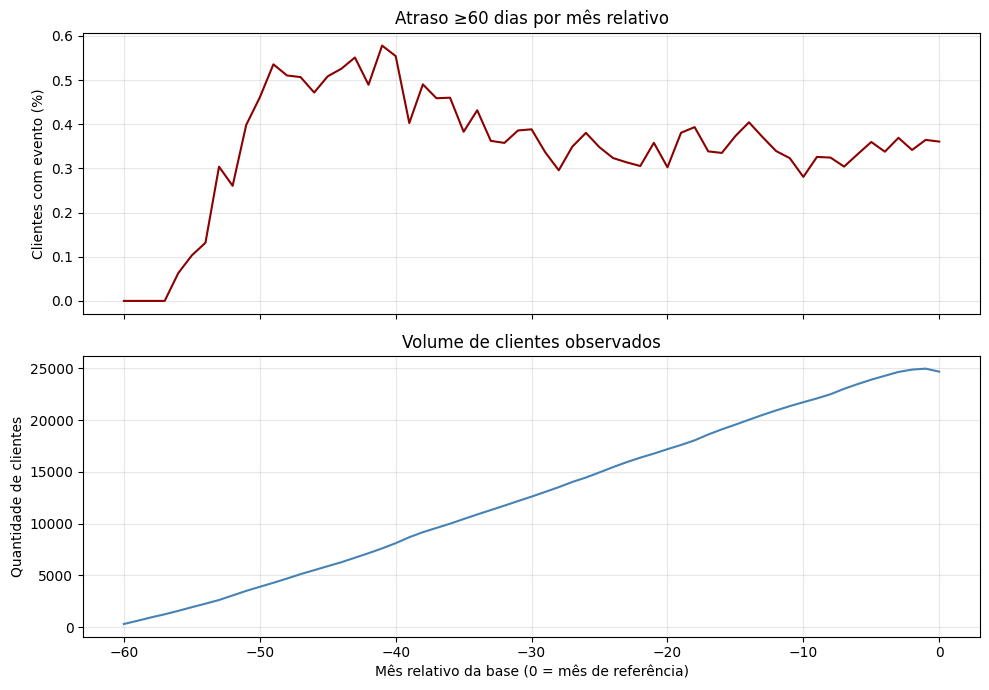

In [165]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True
)

axes[0].plot(
    resumo_mensal.index,
    resumo_mensal["proporcao_atraso"] * 100,
    color="darkred"
)
axes[0].set_title("Atraso ≥60 dias por mês relativo")
axes[0].set_ylabel("Clientes com evento (%)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    resumo_mensal.index,
    resumo_mensal["clientes_observados"],
    color="steelblue"
)
axes[1].set_title("Volume de clientes observados")
axes[1].set_ylabel("Quantidade de clientes")
axes[1].set_xlabel("Mês relativo da base (0 = mês de referência)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretação — evolução dos atrasos no histórico observado

A proporção mensal de clientes com atraso ≥60 dias apresenta oscilações ao longo do período analisado, sem evidenciar uma tendência contínua de crescimento ou redução.

Observa-se também que o volume de clientes com registros disponíveis é significativamente menor nos meses mais antigos, aumentando à medida que se aproxima do mês de referência (0).

Essa diferença na quantidade de clientes observados limita a comparação direta entre os meses, pois as proporções são calculadas sobre populações de tamanhos distintos.

Portanto, os gráficos descrevem o comportamento dos atrasos no histórico disponível, mas não permitem concluir que houve melhora ou piora efetiva do risco de crédito ao longo do tempo.

## 15. Análise de sensibilidade — janela fixa de 12 meses e desbalanceamento

A análise principal considerou a ocorrência de atraso ≥60 dias
em todo o histórico disponível, com diferentes tempos de observação.

Como análise de sensibilidade, foi considerado um intervalo comum
de 12 meses, entre os meses relativos -11 e 0. Foram selecionados
clientes com registros em todos os meses desse intervalo.

Nesse cenário, os modelos foram avaliados com separação por grupos
de perfis cadastrais idênticos. Também foram comparadas configurações
da regressão logística com e sem sobreamostragem aleatória.

A janela fixa uniformiza o período utilizado para construir o alvo.
Entretanto, como a data de coleta do cadastro é desconhecida,
esse cenário não comprova uma previsão de atraso futuro.

A análise principal foi preservada. As métricas dos dois cenários
não são diretamente comparáveis, pois suas populações, proporções
de positivos e estratégias de separação entre treino e teste diferem.

In [166]:
cobertura_fim = (
    df_janela_modelo["max"]
    .value_counts()
    .sort_index()
    .rename_axis("ultimo_mes_observado")
    .reset_index(name="clientes")
)

cobertura_fim["percentual"] = (
    cobertura_fim["clientes"] / len(df_janela_modelo) * 100
)

cobertura_fim.tail(12)

,ultimo_mes_observado,clientes,percentual
49,-11,416,1.14
50,-10,405,1.11
51,-9,416,1.14
52,-8,365,1.00
53,-7,369,1.01
54,-6,390,1.07
55,-5,390,1.07
56,-4,430,1.18
57,-3,416,1.14
58,-2,459,1.26


In [167]:
ids_12m = df_janela_modelo.loc[
    (df_janela_modelo["min"] <= -11)
    & (df_janela_modelo["max"] == 0)
].index

historico_12m = df_credit_modelo.loc[
    df_credit_modelo["ID"].isin(ids_12m)
    & df_credit_modelo["MONTHS_BALANCE"].between(-11, 0)
].copy()

target_12m = (
    historico_12m.groupby("ID")["ATRASO_60"]
    .max()
    .rename("TARGET_12M")
)

print("Clientes:", len(target_12m))
print("Clientes com atraso no intervalo:", target_12m.sum())
print(f"Proporção de positivos: {target_12m.mean():.2%}")

Clientes: 17238
Clientes com atraso no intervalo: 178
Proporção de positivos: 1.03%


In [168]:
base_12m = X.copy()
base_12m["ID"] = df_modelo["ID"]

base_12m = base_12m.merge(
    target_12m.reset_index(),
    on="ID",
    how="inner",
    validate="one_to_one"
)

X_12m = base_12m.drop(columns=["ID", "TARGET_12M"])
y_12m = base_12m["TARGET_12M"].copy()

print("Características:", X_12m.shape)
print("Respostas:", y_12m.shape)
print("IDs duplicados:", base_12m["ID"].duplicated().sum())
print("TARGET ausente:", y_12m.isna().sum())

Características: (17238, 18)
Respostas: (17238,)
IDs duplicados: 0
TARGET ausente: 0


In [169]:
grupos_12m = (
    X_12m.groupby(
        X_12m.columns.tolist(),
        dropna=False,
        sort=False
    ).ngroup()
)

divisao_12m = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

idx_treino_12m, idx_teste_12m = next(
    divisao_12m.split(X_12m, y_12m, groups=grupos_12m)
)

X_train_12m = X_12m.iloc[idx_treino_12m].copy()
X_test_12m = X_12m.iloc[idx_teste_12m].copy()

y_train_12m = y_12m.iloc[idx_treino_12m].copy()
y_test_12m = y_12m.iloc[idx_teste_12m].copy()

grupos_train_12m = grupos_12m.iloc[idx_treino_12m]
grupos_test_12m = grupos_12m.iloc[idx_teste_12m]

print("Treino:", X_train_12m.shape)
print("Teste:", X_test_12m.shape)
print("Positivos no treino:", y_train_12m.sum())
print("Positivos no teste:", y_test_12m.sum())
print(
    "Grupos compartilhados:",
    len(set(grupos_train_12m) & set(grupos_test_12m))
)

Treino: (13779, 18)
Teste: (3459, 18)
Positivos no treino: 151
Positivos no teste: 27
Grupos compartilhados: 0


In [170]:
cv_12m = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

resultados_12m = []

for nome, modelo in [
    ("Regressão logística", modelo_logistico),
    ("Árvore de decisão", modelo_arvore),
    ("Random Forest", modelo_rf),
    ("Gradient Boosting", modelo_gb)
]:
    scores = cross_val_score(
        clone(modelo),
        X_train_12m,
        y_train_12m,
        groups=grupos_train_12m,
        cv=cv_12m,
        scoring="average_precision"
    )

    resultados_12m.append({
        "modelo": nome,
        "AP_media": scores.mean(),
        "AP_desvio": scores.std()
    })

comparacao_12m = (
    pd.DataFrame(resultados_12m)
    .sort_values("AP_media", ascending=False)
)

comparacao_12m.style.format({
    "AP_media": "{:.4f}",
    "AP_desvio": "{:.4f}"
})

,modelo,AP_media,AP_desvio
0,Regressão logística,0.0244,0.0157
3,Gradient Boosting,0.0223,0.0130
2,Random Forest,0.0139,0.0023
1,Árvore de decisão,0.0124,0.0024


In [171]:
import importlib.util

print(
    "imbalanced-learn disponível:",
    importlib.util.find_spec("imblearn") is not None
)

imbalanced-learn disponível: True


### Tratamento do desbalanceamento

Foram comparadas duas configurações da regressão logística:
sem pesos e sem reamostragem; e sem pesos, com sobreamostragem
aleatória da classe positiva.

A sobreamostragem repetiu registros positivos até atingir
uma razão de um positivo para cada cinco negativos.
Ela não criou novos clientes nem informações adicionais.

A reamostragem foi aplicada somente à parcela de treinamento
de cada rodada da validação cruzada. As parcelas de validação
e o conjunto de teste mantiveram suas distribuições originais.

As configurações foram comparadas nas mesmas divisões por grupos,
utilizando Average Precision. A configuração sem reamostragem
apresentou AP média de 0,0387, contra 0,0378 com sobreamostragem.
Essa pequena diferença não demonstra superioridade estatística;
foi mantida a configuração mais simples.

In [172]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

modelo_ros_12m = ImbPipeline([
    ("preprocessamento", clone(preprocessador)),
    ("reamostragem", RandomOverSampler(
        sampling_strategy=0.20,
        random_state=RANDOM_STATE
    )),
    ("modelo", LogisticRegression(
        C=1.0,
        class_weight=None,
        max_iter=1000
    ))
])

modelo_sem_peso_12m = clone(modelo_logistico).set_params(
    modelo__class_weight=None
)

In [173]:
resultados_ros_12m = []

for nome, modelo in [
    ("Sem pesos e sem reamostragem", modelo_sem_peso_12m),
    ("Sobreamostragem aleatória", modelo_ros_12m)
]:
    scores = cross_val_score(
        modelo,
        X_train_12m,
        y_train_12m,
        groups=grupos_train_12m,
        cv=cv_12m,
        scoring="average_precision"
    )

    resultados_ros_12m.append({
        "configuracao": nome,
        "AP_media": scores.mean(),
        "AP_desvio": scores.std()
    })

pd.DataFrame(resultados_ros_12m).style.format({
    "AP_media": "{:.4f}",
    "AP_desvio": "{:.4f}"
})

,configuracao,AP_media,AP_desvio
0,Sem pesos e sem reamostragem,0.0387,0.0223
1,Sobreamostragem aleatória,0.0378,0.0213


In [174]:
modelo_final_12m = clone(modelo_sem_peso_12m)

modelo_final_12m.fit(
    X_train_12m,
    y_train_12m
)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputacao',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escala',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'IDADE_ANOS',
                                                   'EMPREGO_CODIGO_ESPECIAL',
                                                   'TEMPO_EMPREGO_ANOS']),
                                                 ('ca...',
                                                  Pipeline(steps=[('imputacao',
                                                                   SimpleImputer(fill_value='Nao_informado',
                                                                                 strategy='constant')),
                                                                  ('codificacao',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('modelo', LogisticRegression(max_iter=1000))])

In [175]:
pred_12m = modelo_final_12m.predict(X_test_12m)
prob_12m = modelo_final_12m.predict_proba(X_test_12m)[:, 1]

print(classification_report(
    y_test_12m,
    pred_12m,
    digits=4,
    zero_division=0
))

print(f"ROC AUC: {roc_auc_score(y_test_12m, prob_12m):.4f}")
print(
    f"Average Precision: "
    f"{average_precision_score(y_test_12m, prob_12m):.4f}"
)
print(f"Proporção de positivos: {y_test_12m.mean():.4f}")

pd.DataFrame(
    confusion_matrix(y_test_12m, pred_12m, labels=[0, 1]),
    index=["Real 0", "Real 1"],
    columns=["Previsto 0", "Previsto 1"]
)

              precision    recall  f1-score   support

           0     0.9922    1.0000    0.9961      3432
           1     0.0000    0.0000    0.0000        27

    accuracy                         0.9922      3459
   macro avg     0.4961    0.5000    0.4980      3459
weighted avg     0.9844    0.9922    0.9883      3459

ROC AUC: 0.6529
Average Precision: 0.0859
Proporção de positivos: 0.0078


,Previsto 0,Previsto 1
Real 0,3432,0
Real 1,27,0


In [176]:
prob_oof_12m = cross_val_predict(
    clone(modelo_sem_peso_12m),
    X_train_12m,
    y_train_12m,
    groups=grupos_train_12m,
    cv=cv_12m,
    method="predict_proba"
)[:, 1]

print("Pontuações:", len(prob_oof_12m))
print("Primeiras pontuações:", prob_oof_12m[:10])

Pontuações: 13779
Primeiras pontuações: [0.01443589 0.01443589 0.02257822 0.00424186 0.00424186 0.01304612
 0.0103325  0.01332795 0.00590658 0.00590658]


In [177]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

resultados_limiares_12m = []

for limiar in [0.005, 0.01, 0.02, 0.03, 0.05, 0.10, 0.50]:
    previsoes = (prob_oof_12m >= limiar).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train_12m,
        previsoes,
        labels=[0, 1]
    ).ravel()

    resultados_limiares_12m.append({
        "limiar": limiar,
        "precisao": precision_score(
            y_train_12m, previsoes, zero_division=0
        ),
        "recall": recall_score(
            y_train_12m, previsoes, zero_division=0
        ),
        "F1": f1_score(
            y_train_12m, previsoes, zero_division=0
        ),
        "atrasos_identificados": tp,
        "falsos_positivos": fp,
        "atrasos_nao_identificados": fn
    })

tabela_limiares_12m = pd.DataFrame(resultados_limiares_12m)

tabela_limiares_12m.style.format({
    "limiar": "{:.3f}",
    "precisao": "{:.2%}",
    "recall": "{:.2%}",
    "F1": "{:.4f}"
})

,limiar,precisao,recall,F1,atrasos_identificados,falsos_positivos,atrasos_nao_identificados
0,0.005,1.05%,76.82%,0.0206,116,10969,35
1,0.010,1.15%,48.34%,0.0225,73,6277,78
2,0.020,1.62%,13.91%,0.0290,21,1277,130
3,0.030,2.36%,5.30%,0.0327,8,331,143
4,0.050,7.35%,3.31%,0.0457,5,63,146
5,0.100,25.00%,0.66%,0.0129,1,3,150
6,0.500,0.00%,0.00%,0.0000,0,0,151


In [178]:
limiar_12m = 0.05

pred_limiar_12m = (prob_12m >= limiar_12m).astype(int)

print(classification_report(
    y_test_12m,
    pred_limiar_12m,
    digits=4,
    zero_division=0
))

matriz_12m = pd.DataFrame(
    confusion_matrix(
        y_test_12m,
        pred_limiar_12m,
        labels=[0, 1]
    ),
    index=["Real 0", "Real 1"],
    columns=["Previsto 0", "Previsto 1"]
)

display(matriz_12m)

              precision    recall  f1-score   support

           0     0.9930    0.9968    0.9949      3432
           1     0.2143    0.1111    0.1463        27

    accuracy                         0.9899      3459
   macro avg     0.6037    0.5540    0.5706      3459
weighted avg     0.9870    0.9899    0.9883      3459



,Previsto 0,Previsto 1
Real 0,3421,11
Real 1,24,3


### Resultado do experimento com janela de 12 meses

A análise considerou 17.238 clientes com histórico completo entre
os meses relativos -11 e 0. Nesse intervalo, 178 clientes apresentaram
pelo menos um atraso igual ou superior a 60 dias, correspondendo
a aproximadamente 1,03% da amostra.

A separação entre treino e teste impediu o compartilhamento de
perfis cadastrais idênticos. Entre as configurações avaliadas,
a regressão logística sem pesos e sem reamostragem apresentou
a maior Average Precision média na validação cruzada, de 0,0387.
A sobreamostragem aleatória não trouxe melhora nessa comparação.

No teste, o modelo apresentou ROC AUC de 0,6529 e Average Precision
de 0,0859, com proporção de positivos de 0,78%.

O limiar de 0,05 foi escolhido pelo maior F1 entre os valores
avaliados com pontuações de validação cruzada do treino.
No teste, identificou 3 dos 27 casos positivos, com 11 falsos
positivos, precisão de 21,43% e recall de 11,11%.

Os resultados indicam alguma capacidade de ordenar clientes
conforme o risco do evento definido, mas baixa sensibilidade
na classificação. Como o teste contém apenas 27 casos positivos,
as métricas também estão sujeitas a elevada incerteza.

A janela uniforme reduz a diferença de tempo de observação,
mas não estabelece uma previsão prospectiva: não há informação
que confirme que os dados cadastrais foram coletados antes do
período usado para construir o alvo. A avaliação permanece
exploratória, e o modelo não foi validado para uso operacional
em decisões de crédito.

## Conclusão geral

O projeto desenvolveu modelos de classificação para identificar
clientes com pelo menos um atraso igual ou superior a 60 dias,
conforme o histórico disponível.

A análise principal preservou os 36.457 clientes presentes nas
duas bases. Foram comparados regressão logística, árvore de decisão,
Random Forest e Gradient Boosting. A validação por grupos de
perfis cadastrais idênticos reduziu a Average Precision média
principalmente da Random Forest e do Gradient Boosting.
Na regressão logística, as médias ficaram próximas.
Os resultados evidenciam a importância da estratégia de
separação dos dados na avaliação dos modelos.

A regressão logística apresentou a maior Average Precision média
na comparação por grupos. O ajuste de parâmetros e do limiar
permitiu explorar diferentes relações entre identificação de
atrasos e falsos positivos, mas a sensibilidade permaneceu baixa.

Como análise de sensibilidade, foi construída uma segunda base
com 17.238 clientes observados durante os mesmos 12 meses.
A sobreamostragem aleatória não melhorou a Average Precision média
em relação à configuração sem reamostragem. No teste, o modelo
selecionado apresentou ROC AUC de 0,6529 e Average Precision de
0,0859. Com limiar de 0,05, identificou 3 dos 27 casos positivos.

A clusterização identificou dois segmentos com diferenças de idade,
renda e composição familiar. Entretanto, esses segmentos não
apresentaram uma separação consistente das proporções de atraso
entre treino e teste.

As principais limitações são o desbalanceamento das classes,
a repetição de perfis cadastrais, a ausência de datas de coleta
do cadastro e a pequena quantidade de eventos positivos.
Na análise principal, também há diferenças no tempo de observação.

O trabalho atende ao objetivo acadêmico de construir e avaliar
modelos para um alvo definido a partir do histórico de crédito.
Os resultados, porém, não demonstram desempenho suficiente
para recomendar decisões automáticas de concessão.

Para uma aplicação prospectiva, seriam necessários dados cadastrais datados, uma data de corte anterior ao período de desempenho e uma avaliação em amostra independente, além da definição dos custos dos erros de classificação.

Ambientes e versões das bibliotecas:

In [179]:
import sys
import sklearn
import jinja2

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Jinja2:", jinja2.__version__)

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
pandas: 2.2.3
NumPy: 2.1.3
scikit-learn: 1.6.1
Jinja2: 3.1.6


In [180]:
import matplotlib

print("Matplotlib:", matplotlib.__version__)

Matplotlib: 3.10.0


In [181]:
import imblearn

print("imbalanced-learn:", imblearn.__version__)

imbalanced-learn: 0.14.2


In [182]:
import seaborn as sns

print("seaborn:", sns.__version__)

seaborn: 0.13.2


## Referências

### Dados e referência para construção do alvo

- RIKDIFOS. Credit Card Approval Prediction. Kaggle.
  https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction

- RIKDIFOS. EDA & Vintage Analysis. Kaggle.
  https://www.kaggle.com/code/rikdifos/eda-vintage-analysis

A análise Vintage foi utilizada como referência para discutir
o critério de atraso e o tempo de observação. O projeto não
reproduziu integralmente a metodologia desse notebook.

### Documentação das técnicas

- SCIKIT-LEARN. User Guide — versão 1.6.
  Pré-processamento, classificação, validação, métricas,
  interpretação e clusterização.
  https://scikit-learn.org/1.6/user_guide.html

- IMBALANCED-LEARN. Over-sampling.
  Referência para sobreamostragem aleatória.
  https://imbalanced-learn.org/stable/over_sampling.html

